# SWIR Processed-Box Analysis: Impact-Level Bruising Dynamics

This notebook uses the project train+validation SWIR split H5 files in `data/splits/train` and `data/splits/val`.

Analysis rule:
- `t0` uses `sound*` boxes as the healthy baseline
- `t1` and `t3` use only `bruised*` boxes
- `t2` is excluded
- bruised boxes are reduced to a centered `20x20` patch before analysis, matching the original notebook

Impact groups:
- low impact: `280`, `281`, `282`, `283`, `290`, `291`, `292`, `293`
- high impact: `284`, `285`, `294`, `295`

Additional condition groups:
- warm condition: complete train+validation warm-condition samples
- cold condition: complete train+validation cold-condition samples
- whole sample: all complete train+validation samples

Wavelength values are mapped with `/home/emahan/sysops/HIPPA/bruising/references/swir_hippa_wl_calib_rounded.npy`, following `/home/emahan/sysops/HIPPA/hanif/band_wavelength_mapping.ipynb`.


In [1]:
from pathlib import Path
import math
import re
import gc

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from tqdm.auto import tqdm

PROJECT_ROOT = Path('/home/emahan/sysops/HIPPA/hanif/bruising_detection')
SPLIT_DIRS = [PROJECT_ROOT / 'data' / 'splits' / 'train', PROJECT_ROOT / 'data' / 'splits' / 'val']
SWIR_WL_CALIB_PATH = Path('/home/emahan/sysops/HIPPA/bruising/references/swir_hippa_wl_calib_rounded.npy')

TIMEPOINTS = ('t0', 't1', 't3')
SENSOR_PREFIX = 'SWIR'
TOP_K = 10

CODE_RE = re.compile(r'^MICROTEC_(\d+)_processed_boxes\.h5$')

pd.set_option('display.max_colwidth', 160)
plt.rcParams['figure.figsize'] = (12, 4)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
IMPACT_COLORS = {'baseline': '#2f3a4a', 't1': '#d95f02', 't3': '#1b9e77', 'low_impact': '#3b82f6', 'high_impact': '#ef4444'}

GROUP_DISPLAY_NAMES = {
    'low_impact': 'Low Impact',
    'high_impact': 'High Impact',
    'warm_condition': 'Warm Condition',
    'cold_condition': 'Cold Condition',
    'all_train_val_samples': 'All Train+Validation Samples',
}


def display_group_name(group_name: str) -> str:
    return GROUP_DISPLAY_NAMES.get(group_name, group_name.replace('_', ' ').title())



/home/emahan/.conda/envs/hippa/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Train, Validation, and Test Split Summary

This descriptive block summarizes the saved split files before the train+validation-only EDA sections below. It counts samples in train, validation, and test, plus warm/cold condition and low/high impact membership.


In [13]:
SPLIT_SUMMARY_DIRS = {
    'train': PROJECT_ROOT / 'data' / 'splits' / 'train',
    'validation': PROJECT_ROOT / 'data' / 'splits' / 'val',
    'test': PROJECT_ROOT / 'data' / 'splits' / 'test',
}

SUMMARY_WARM_PREFIXES = ('28',)
SUMMARY_COLD_PREFIXES = ('29',)
SUMMARY_LOW_IMPACT_PREFIXES = ('280', '281', '282', '283', '290', '291', '292', '293')
SUMMARY_HIGH_IMPACT_PREFIXES = ('284', '285', '294', '295')


def split_sample_codes(split_dir: Path) -> list[str]:
    codes = []
    for path in sorted(split_dir.glob('MICROTEC_*_processed_boxes.h5')):
        match = CODE_RE.match(path.name)
        if match:
            codes.append(match.group(1))
    return codes


def count_prefixes(codes: list[str], prefixes: tuple[str, ...]) -> int:
    return sum(any(code.startswith(prefix) for prefix in prefixes) for code in codes)


split_codes = {split: split_sample_codes(split_dir) for split, split_dir in SPLIT_SUMMARY_DIRS.items()}

split_summary_rows = []
for split, codes in split_codes.items():
    split_summary_rows.append({
        'split': split,
        'apples': len(codes),
        'warm_condition': count_prefixes(codes, SUMMARY_WARM_PREFIXES),
        'cold_condition': count_prefixes(codes, SUMMARY_COLD_PREFIXES),
        'low_impact': count_prefixes(codes, SUMMARY_LOW_IMPACT_PREFIXES),
        'high_impact': count_prefixes(codes, SUMMARY_HIGH_IMPACT_PREFIXES),
        'samples': len(codes) * 4,
        'warm_condition_samples': count_prefixes(codes, SUMMARY_WARM_PREFIXES) * 4,
        'cold_condition_samples': count_prefixes(codes, SUMMARY_COLD_PREFIXES) * 4,
        'low_impact_samples': count_prefixes(codes, SUMMARY_LOW_IMPACT_PREFIXES) * 4,
        'high_impact_samples': count_prefixes(codes, SUMMARY_HIGH_IMPACT_PREFIXES) * 4,
    })

all_split_codes = [code for codes in split_codes.values() for code in codes]
split_summary_rows.append({
    'split': 'total',
    'apples': len(all_split_codes),
    'warm_condition': count_prefixes(all_split_codes, SUMMARY_WARM_PREFIXES),
    'cold_condition': count_prefixes(all_split_codes, SUMMARY_COLD_PREFIXES),
    'low_impact': count_prefixes(all_split_codes, SUMMARY_LOW_IMPACT_PREFIXES),
    'high_impact': count_prefixes(all_split_codes, SUMMARY_HIGH_IMPACT_PREFIXES),
    'samples': len(all_split_codes) * 4,
    'warm_condition_samples': count_prefixes(all_split_codes, SUMMARY_WARM_PREFIXES) * 4,
    'cold_condition_samples': count_prefixes(all_split_codes, SUMMARY_COLD_PREFIXES) * 4,
    'low_impact_samples': count_prefixes(all_split_codes, SUMMARY_LOW_IMPACT_PREFIXES) * 4,
    'high_impact_samples': count_prefixes(all_split_codes, SUMMARY_HIGH_IMPACT_PREFIXES) * 4,
    
})

split_summary_df = pd.DataFrame(split_summary_rows)

display(Markdown('**Sample counts by split, condition, and impact level**'))
display(split_summary_df)


**Sample counts by split, condition, and impact level**

,split,apples,warm_condition,cold_condition,low_impact,high_impact,samples,warm_condition_samples,cold_condition_samples,low_impact_samples,high_impact_samples
0,train,94,46,48,65,29,376,184,192,260,116
1,validation,12,6,6,7,5,48,24,24,28,20
2,test,12,6,6,6,6,48,24,24,24,24
3,total,118,58,60,78,40,472,232,240,312,160


In [3]:
def extract_code(path: Path) -> str | None:
    match = CODE_RE.match(path.name)
    return match.group(1) if match else None


H5_PATH_BY_CODE = {}
for split_dir in SPLIT_DIRS:
    for path in sorted(split_dir.glob('MICROTEC_*_processed_boxes.h5')):
        code = extract_code(path)
        if code is not None:
            H5_PATH_BY_CODE[code] = path


def processed_h5_path(code: str) -> Path:
    return H5_PATH_BY_CODE[code]


def _decode_attr(value):
    if isinstance(value, bytes):
        return value.decode('utf-8')
    return value


def dataset_roi_type(name: str, dataset: h5py.Dataset) -> str:
    attr = _decode_attr(dataset.attrs.get('roi_type', ''))
    if attr:
        return str(attr)
    lname = name.lower()
    if lname.startswith('sound'):
        return 'sound'
    if lname.startswith('bruised'):
        return 'bruised'
    return 'unknown'


def inventory_for_code(code: str) -> tuple[pd.DataFrame, bool]:
    path = processed_h5_path(code)
    rows = []
    with h5py.File(path, 'r') as handle:
        for timepoint in TIMEPOINTS:
            group_name = f'{SENSOR_PREFIX}_{timepoint}'
            group_exists = group_name in handle
            sound_boxes = 0
            bruised_boxes = 0
            n_bands = None
            source_file = ''
            if group_exists:
                group = handle[group_name]
                source_file = _decode_attr(group.attrs.get('source_file', ''))
                for ds_name, ds in group.items():
                    if not isinstance(ds, h5py.Dataset):
                        continue
                    roi_type = dataset_roi_type(ds_name, ds)
                    if roi_type == 'sound':
                        sound_boxes += 1
                    elif roi_type == 'bruised':
                        bruised_boxes += 1
                    n_bands = int(ds.shape[-1])
            rows.append({
                'sample_code': code,
                'timepoint': timepoint,
                'group_exists': group_exists,
                'sound_boxes': sound_boxes,
                'bruised_boxes': bruised_boxes,
                'n_bands': n_bands,
                'source_file': source_file,
            })
    df = pd.DataFrame(rows)
    is_complete = bool(
        df['group_exists'].all()
        and (df['sound_boxes'] > 0).all()
        and (df['bruised_boxes'] > 0).all()
    )
    return df, is_complete


inventory_rows = []
complete_codes = []
incomplete_codes = []

for path in sorted(H5_PATH_BY_CODE.values()):
    code = extract_code(path)
    if code is None:
        continue
    code_df, is_complete = inventory_for_code(code)
    inventory_rows.extend(code_df.to_dict('records'))
    if is_complete:
        complete_codes.append(code)
    else:
        incomplete_codes.append(code)

inventory_df = pd.DataFrame(inventory_rows).sort_values(['sample_code', 'timepoint']).reset_index(drop=True)
inventory_summary_df = (
    inventory_df
    .groupby('sample_code', as_index=False)
    .agg(
        timepoints_found=('group_exists', 'sum'),
        min_sound_boxes=('sound_boxes', 'min'),
        min_bruised_boxes=('bruised_boxes', 'min'),
        bands=('n_bands', 'max'),
    )
    .sort_values('sample_code')
    .reset_index(drop=True)
)

print(f'Processed H5 files found: {inventory_summary_df.shape[0]}')
print(f'Complete samples with SWIR_t0, SWIR_t1, SWIR_t3 and both box types: {len(complete_codes)}')
print(f'Incomplete samples: {len(incomplete_codes)}')
if incomplete_codes:
    print('Incomplete codes:', incomplete_codes)

display(Markdown('**Per-sample inventory summary**'))
display(inventory_summary_df)


Processed H5 files found: 106
Complete samples with SWIR_t0, SWIR_t1, SWIR_t3 and both box types: 106
Incomplete samples: 0


**Per-sample inventory summary**

,sample_code,timepoints_found,min_sound_boxes,min_bruised_boxes,bands
0,28002,3,4,4,220
1,28003,3,4,4,220
2,28004,3,4,4,220
3,28005,3,4,4,220
4,28006,3,4,4,220
...,...,...,...,...,...
101,29504,3,4,4,220
102,29506,3,4,4,220
103,29507,3,4,4,220
104,29508,3,4,4,220


In [4]:
LOW_IMPACT_PREFIXES = ('280', '281', '282', '283', '290', '291', '292', '293')
HIGH_IMPACT_PREFIXES = ('284', '285', '294', '295')
IMPACT_GROUPS = {
    'low_impact': LOW_IMPACT_PREFIXES,
    'high_impact': HIGH_IMPACT_PREFIXES,
}


def codes_for_prefixes(prefixes) -> list[str]:
    return sorted(code for code in complete_codes if any(code.startswith(prefix) for prefix in prefixes))


REQUESTED_GROUPS = {name: codes_for_prefixes(prefixes) for name, prefixes in IMPACT_GROUPS.items()}

missing_groups = [name for name, codes in REQUESTED_GROUPS.items() if not codes]
if missing_groups:
    raise ValueError(f'No complete samples found for: {missing_groups}')

group_summary_rows = []
group_timepoint_rows = []
for name, prefixes in IMPACT_GROUPS.items():
    codes = REQUESTED_GROUPS[name]
    group_inventory = inventory_df[inventory_df['sample_code'].isin(codes)].copy()
    group_summary_rows.append({
        'impact_group': name,
        'n_samples': len(codes),
    })
    for timepoint in TIMEPOINTS:
        subset = group_inventory[group_inventory['timepoint'] == timepoint]
        group_timepoint_rows.append({
            'impact_group': name,
            'timepoint': timepoint,
            'samples': subset['sample_code'].nunique(),
            'sound_boxes': int(subset['sound_boxes'].sum()),
            'bruised_boxes': int(subset['bruised_boxes'].sum()),
        })

group_summary_df = pd.DataFrame(group_summary_rows)
group_timepoint_df = pd.DataFrame(group_timepoint_rows)

display(Markdown('**Impact group summary**'))
display(group_summary_df)

display(Markdown('**Impact group x timepoint box counts**'))
display(group_timepoint_df)


**Impact group summary**

,impact_group,n_samples
0,low_impact,72
1,high_impact,34


**Impact group x timepoint box counts**

,impact_group,timepoint,samples,sound_boxes,bruised_boxes
0,low_impact,t0,72,288,288
1,low_impact,t1,72,288,288
2,low_impact,t3,72,288,288
3,high_impact,t0,34,136,136
4,high_impact,t1,34,136,136
5,high_impact,t3,34,136,136


In [5]:
def _get_wavelength_axis(n_bands: int) -> np.ndarray:
    wavelengths = np.load(SWIR_WL_CALIB_PATH).astype(np.float32)
    if wavelengths.shape[0] == n_bands:
        return wavelengths
    if wavelengths.shape[0] > n_bands:
        return wavelengths[:n_bands]
    raise ValueError(
        f'SWIR wavelength mapping has {wavelengths.shape[0]} bands, but the data has {n_bands} bands.'
    )


def _sorted_dataset_names(group: h5py.Group, roi_type: str) -> list[str]:
    names = []
    for ds_name, ds in group.items():
        if not isinstance(ds, h5py.Dataset):
            continue
        if dataset_roi_type(ds_name, ds) == roi_type:
            names.append(ds_name)

    def sort_key(name: str):
        match = re.search(r'(\d+)$', name)
        return (int(match.group(1)) if match else 0, name)

    return sorted(names, key=sort_key)


def center_crop_cube(cube: np.ndarray, crop_h: int, crop_w: int) -> np.ndarray:
    array = np.asarray(cube)
    if array.ndim != 3:
        raise ValueError(f'Expected a 3D cube, got shape={array.shape}')

    height, width, _ = array.shape
    if crop_h > height or crop_w > width:
        raise ValueError(
            f'Center crop {crop_h}x{crop_w} is larger than cube shape {array.shape}'
        )

    y0 = (height - crop_h) // 2
    x0 = (width - crop_w) // 2
    return array[y0:y0 + crop_h, x0:x0 + crop_w, :]


def load_box_cubes(code: str, timepoint: str, roi_type: str) -> list[np.ndarray]:
    path = processed_h5_path(code)
    group_name = f'{SENSOR_PREFIX}_{timepoint}'
    with h5py.File(path, 'r') as handle:
        if group_name not in handle:
            raise KeyError(f'{group_name} is missing in {path.name}')
        group = handle[group_name]
        names = _sorted_dataset_names(group, roi_type)
        cubes = [group[name][()] for name in names]

    if not cubes:
        raise ValueError(f'No {roi_type} cubes found for {code} at {timepoint}')

    if roi_type == 'bruised':
        cubes = [center_crop_cube(cube, crop_h=20, crop_w=20) for cube in cubes]

    return cubes


def cube_band_values(cube: np.ndarray) -> np.ndarray:
    array = np.asarray(cube, dtype=np.float32)
    if array.ndim != 3:
        raise ValueError(f'Expected a 3D cube, got shape={array.shape}')
    return array.reshape(-1, array.shape[-1])


def compute_group_average_spectra(sample_codes, timepoints=TIMEPOINTS):
    sound_lists = {t: [] for t in timepoints}
    bruised_lists = {t: [] for t in timepoints}

    sound_sum = {t: None for t in timepoints}
    bruised_sum = {t: None for t in timepoints}
    sound_pixels = {t: 0 for t in timepoints}
    bruised_pixels = {t: 0 for t in timepoints}

    iterator = tqdm(sample_codes, desc='processed-box spectra', unit='sample')
    for code in iterator:
        for timepoint in timepoints:
            for cube in load_box_cubes(code, timepoint, 'sound'):
                values = cube_band_values(cube)
                sound_lists[timepoint].append(values.mean(axis=0))
                total = values.sum(axis=0, dtype=np.float64)
                sound_sum[timepoint] = total if sound_sum[timepoint] is None else (sound_sum[timepoint] + total)
                sound_pixels[timepoint] += int(values.shape[0])

            for cube in load_box_cubes(code, timepoint, 'bruised'):
                values = cube_band_values(cube)
                bruised_lists[timepoint].append(values.mean(axis=0))
                total = values.sum(axis=0, dtype=np.float64)
                bruised_sum[timepoint] = total if bruised_sum[timepoint] is None else (bruised_sum[timepoint] + total)
                bruised_pixels[timepoint] += int(values.shape[0])

    sound_stack = {t: np.stack(sound_lists[t], axis=0) for t in timepoints}
    bruised_stack = {t: np.stack(bruised_lists[t], axis=0) for t in timepoints}

    n_bands = next(iter(sound_stack.values())).shape[1]
    bands = _get_wavelength_axis(n_bands)

    return {
        'codes': list(sample_codes),
        'timepoints': list(timepoints),
        'bands': bands,
        'sound_mean': {
            t: (sound_sum[t] / sound_pixels[t]).astype(np.float32)
            for t in timepoints
        },
        'bruised_mean': {
            t: (bruised_sum[t] / bruised_pixels[t]).astype(np.float32)
            for t in timepoints
        },
        'sound_stack': sound_stack,
        'bruised_stack': bruised_stack,
        'sound_box_counts': {t: len(sound_lists[t]) for t in timepoints},
        'bruised_box_counts': {t: len(bruised_lists[t]) for t in timepoints},
        'sound_pixel_counts': sound_pixels,
        'bruised_pixel_counts': bruised_pixels,
    }


Example bruised box: timepoint=t3, dataset=bruised1, full_shape=(160, 160, 220), center_crop_shape=(20, 20, 220), center_crop_xy=(70, 70)


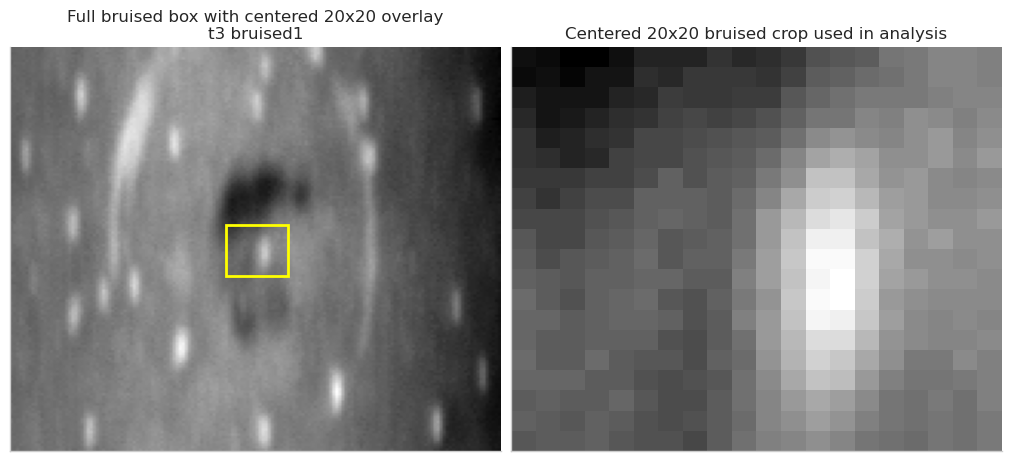

In [6]:
from matplotlib.patches import Rectangle

EXAMPLE_SAMPLE_CODE = REQUESTED_GROUPS['high_impact'][0]
EXAMPLE_TIMEPOINT = 't3'
EXAMPLE_BRUISED_DATASET = 'bruised1'
EXAMPLE_BAND = 99

example_path = processed_h5_path(EXAMPLE_SAMPLE_CODE)
example_group_name = f'{SENSOR_PREFIX}_{EXAMPLE_TIMEPOINT}'

with h5py.File(example_path, 'r') as handle:
    example_cube = handle[example_group_name][EXAMPLE_BRUISED_DATASET][()]

example_center_crop = center_crop_cube(example_cube, crop_h=20, crop_w=20)
band_index = min(EXAMPLE_BAND, example_cube.shape[2] - 1)

height, width, _ = example_cube.shape
crop_h, crop_w = example_center_crop.shape[:2]
y0 = (height - crop_h) // 2
x0 = (width - crop_w) // 2

print(
    f'Example bruised box: timepoint={EXAMPLE_TIMEPOINT}, dataset={EXAMPLE_BRUISED_DATASET}, '
    f'full_shape={example_cube.shape}, center_crop_shape={example_center_crop.shape}, '
    f'center_crop_xy=({x0}, {y0})'
)

fig, axs = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)

axs[0].imshow(example_cube[:, :, band_index], cmap='gray', aspect='auto')
axs[0].add_patch(Rectangle((x0, y0), crop_w, crop_h, fill=False, edgecolor='yellow', linewidth=2))
axs[0].set_title(f'Full bruised box with centered 20x20 overlay\n{EXAMPLE_TIMEPOINT} {EXAMPLE_BRUISED_DATASET}')
axs[0].set_xticks([])
axs[0].set_yticks([])

axs[1].imshow(example_center_crop[:, :, band_index], cmap='gray', aspect='auto')
axs[1].set_title('Centered 20x20 bruised crop used in analysis')
axs[1].set_xticks([])
axs[1].set_yticks([])

plt.show()


In [7]:
def impact_baseline(group_data):
    # t0 is intentionally healthy/sound baseline.
    return group_data['sound_mean']['t0']


def impact_curve(group_data, timepoint):
    # Later timepoints use bruised boxes only.
    return group_data['bruised_mean'][timepoint]


def plot_group_top_distinctive_bands(group_name, group_data, top_k=10):
    baseline = impact_baseline(group_data)
    bands = group_data['bands']

    for timepoint in ('t1', 't3'):
        if timepoint not in group_data['timepoints']:
            continue
        curve = impact_curve(group_data, timepoint)
        score = np.abs(curve - baseline)
        idx = np.argsort(score)[::-1][:top_k]

        print(f'[{display_group_name(group_name)}] Top {top_k} changing wavelengths: healthy t0 baseline vs bruised {timepoint}')
        for i, band_index in enumerate(idx, 1):
            print(f'{i}. wavelength={bands[band_index]:.1f} nm: |Δ|={score[band_index]:.6f}')

        fig, ax = plt.subplots(figsize=(12, 4.5))
        ax.plot(bands, score, color=IMPACT_COLORS.get(timepoint, 'crimson'), linewidth=2.2, label=f'|bruised {timepoint} - sound t0|')
        ax.scatter(bands[idx], score[idx], color='black', s=28, zorder=3, label='top wavelengths')
        for band_index in idx[:5]:
            ax.text(float(bands[band_index]), float(score[band_index]), f' {bands[band_index]:.1f}', fontsize=9)
        ax.set_title(f'{display_group_name(group_name)} | strongest wavelength changes from healthy baseline', fontsize=14, weight='bold')
        ax.set_xlabel('Wavelength (nm)')
        ax.set_ylabel('Absolute reflectance change')
        ax.legend(frameon=False)
        plt.tight_layout()
        plt.show()
        plt.close(fig)


def plot_group_sound_vs_bruised_timepoints(group_name, group_data):
    bands = group_data['bands']
    baseline = impact_baseline(group_data)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(bands, baseline, color=IMPACT_COLORS['baseline'], linewidth=2.4, label='healthy baseline (sound t0)')
    for timepoint in ('t1', 't3'):
        if timepoint in group_data['timepoints']:
            ax.plot(bands, impact_curve(group_data, timepoint), color=IMPACT_COLORS[timepoint], linewidth=2.2, label=f'bruised {timepoint}')
    ax.set_title(f'{display_group_name(group_name)} | bruising spectra evolution', fontsize=15, weight='bold')
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel('Mean reflectance')
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def plot_group_bruised_t0_change(group_name, group_data):
    bands = group_data['bands']
    baseline = impact_baseline(group_data)

    fig, axs = plt.subplots(1, 2, figsize=(15, 4.8), constrained_layout=True)
    axs[0].plot(bands, baseline, color=IMPACT_COLORS['baseline'], linewidth=2.4, label='sound t0 baseline')
    for timepoint in ('t1', 't3'):
        if timepoint in group_data['timepoints']:
            axs[0].plot(bands, impact_curve(group_data, timepoint), color=IMPACT_COLORS[timepoint], linewidth=2.2, label=f'bruised {timepoint}')
    axs[0].set_title('Raw mean spectra', fontsize=13, weight='bold')
    axs[0].set_xlabel('Wavelength (nm)')
    axs[0].set_ylabel('Mean reflectance')
    axs[0].legend(frameon=False)

    for timepoint in ('t1', 't3'):
        if timepoint not in group_data['timepoints']:
            continue
        delta = impact_curve(group_data, timepoint) - baseline
        bmax = int(np.argmax(np.abs(delta)))
        axs[1].plot(bands, delta, color=IMPACT_COLORS[timepoint], linewidth=2.2, label=f'bruised {timepoint} - sound t0')
        axs[1].scatter([bands[bmax]], [delta[bmax]], color='black', s=25, zorder=3)
    axs[1].axhline(0.0, color='gray', linestyle=':', linewidth=1.2)
    axs[1].set_title('Change from healthy baseline', fontsize=13, weight='bold')
    axs[1].set_xlabel('Wavelength (nm)')
    axs[1].set_ylabel('Reflectance change')
    axs[1].legend(frameon=False)
    fig.suptitle(f'{display_group_name(group_name)} | bruising dynamics', fontsize=16, weight='bold')
    plt.show()
    plt.close(fig)


def plot_group_temporal_evolution(group_name, group_data):
    labels = ['sound t0'] + [f'bruised {tp}' for tp in ('t1', 't3') if tp in group_data['timepoints']]
    values = [impact_baseline(group_data).mean()] + [impact_curve(group_data, tp).mean() for tp in ('t1', 't3') if tp in group_data['timepoints']]
    colors = [IMPACT_COLORS['baseline']] + [IMPACT_COLORS[tp] for tp in ('t1', 't3') if tp in group_data['timepoints']]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(range(len(values)), values, marker='o', linewidth=2.5, color='#111827')
    ax.scatter(range(len(values)), values, s=85, color=colors, zorder=3)
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels(labels)
    ax.set_title(f'{display_group_name(group_name)} | mean spectral intensity trajectory', fontsize=14, weight='bold')
    ax.set_ylabel('Mean reflectance across wavelengths')
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def plot_group_variance(group_name, group_data):
    bands = group_data['bands']
    fig, ax = plt.subplots(figsize=(12, 5))
    stacks = [('sound t0', group_data['sound_stack']['t0'], IMPACT_COLORS['baseline'])]
    stacks += [(f'bruised {tp}', group_data['bruised_stack'][tp], IMPACT_COLORS[tp]) for tp in ('t1', 't3') if tp in group_data['timepoints']]
    for label, stack, color in stacks:
        mean = stack.mean(axis=0)
        std = stack.std(axis=0)
        ax.plot(bands, mean, color=color, linewidth=2.1, label=label)
        ax.fill_between(bands, mean - std, mean + std, color=color, alpha=0.14)
    ax.set_title(f'{display_group_name(group_name)} | spectral variance (shade = +/-1 std)', fontsize=14, weight='bold')
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel('Mean reflectance')
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


In [8]:
def top_distinctive_nonoverlap_bands_from_group_data(group_data, top_k=5, timepoints=('t1', 't3')):
    bands = group_data['bands']
    baseline_mean = group_data['sound_stack']['t0'].mean(axis=0)
    baseline_std = group_data['sound_stack']['t0'].std(axis=0)

    best_score = np.full(len(bands), -np.inf, dtype=float)
    best_timepoint = np.array([''] * len(bands), dtype=object)

    for timepoint in timepoints:
        if timepoint not in group_data['timepoints']:
            continue
        bruised_stack = group_data['bruised_stack'][timepoint]
        bruised_mean = bruised_stack.mean(axis=0)
        bruised_std = bruised_stack.std(axis=0)
        non_overlap = (baseline_mean + baseline_std < bruised_mean - bruised_std) | (bruised_mean + bruised_std < baseline_mean - baseline_std)
        score = np.where(non_overlap, np.abs(bruised_mean - baseline_mean), -np.inf)
        improved = score > best_score
        best_score[improved] = score[improved]
        best_timepoint[improved] = timepoint

    valid_idx = np.where(np.isfinite(best_score))[0]
    if len(valid_idx) == 0:
        print('No wavelengths satisfy the non-overlap condition.')
        return {'bands': [], 'scores': [], 'timepoints': []}
    top_idx = valid_idx[np.argsort(best_score[valid_idx])[::-1]][:top_k]
    return {'bands': [int(b) for b in top_idx], 'scores': [float(best_score[b]) for b in top_idx], 'timepoints': [str(best_timepoint[b]) for b in top_idx]}


def boxplot_distinctive_bands(group_data, topk_result, group_name):
    if not topk_result['bands']:
        print(f'No distinctive wavelengths available for {group_name}.')
        return
    n_items = len(topk_result['bands'])
    ncols = min(3, n_items)
    nrows = math.ceil(n_items / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()
    bands = group_data['bands']
    baseline_vals = group_data['sound_stack']['t0']
    for ax, band_index, timepoint, score in zip(axes, topk_result['bands'], topk_result['timepoints'], topk_result['scores']):
        bruised_vals = group_data['bruised_stack'][timepoint][:, band_index]
        ax.boxplot([baseline_vals[:, band_index], bruised_vals], labels=['sound t0', f'bruised {timepoint}'], patch_artist=True)
        ax.set_title(f'{display_group_name(group_name)} | {bands[band_index]:.1f} nm\n{timepoint}, score={score:.4f}', fontsize=10, weight='bold')
        ax.set_ylabel('Mean center-crop reflectance')
        ax.grid(alpha=0.2)
    for ax in axes[n_items:]:
        ax.axis('off')
    fig.suptitle(f'Distinctive wavelength boxplots | {display_group_name(group_name)}', fontsize=14, weight='bold')
    plt.show()
    plt.close(fig)


def summarize_group_inputs(group_name, group_data):
    print('ROI / pixel counts used per timepoint:')
    print(f'  t0 baseline: sound_boxes={group_data["sound_box_counts"]["t0"]}, sound_pixels={group_data["sound_pixel_counts"]["t0"]}')
    for timepoint in ('t1', 't3'):
        print(f'  {timepoint}: bruised_boxes={group_data["bruised_box_counts"][timepoint]}, bruised_pixels={group_data["bruised_pixel_counts"][timepoint]}, n_samples={len(group_data["codes"])}')


def run_full_group_analysis(group_name, sample_codes, top_k=TOP_K, show_boxplots=False, section_label='Analysis group'):
    print('\n' + '=' * 70)
    pretty_name = display_group_name(group_name)
    print(f'{section_label}: {pretty_name} | n={len(sample_codes)}')
    group_data = compute_group_average_spectra(sample_codes, timepoints=TIMEPOINTS)
    summarize_group_inputs(group_name, group_data)
    plot_group_top_distinctive_bands(group_name, group_data, top_k=top_k)
    plot_group_sound_vs_bruised_timepoints(group_name, group_data)
    plot_group_bruised_t0_change(group_name, group_data)
    plot_group_temporal_evolution(group_name, group_data)
    plot_group_variance(group_name, group_data)
    topk_result = top_distinctive_nonoverlap_bands_from_group_data(group_data, top_k=top_k)
    print(f'Non-overlap top wavelengths for {group_name}: {topk_result}')
    if show_boxplots:
        boxplot_distinctive_bands(group_data, topk_result, group_name)
    gc.collect()
    return {'group_data': group_data, 'topk_result': topk_result}



Impact group: Low Impact | n=72


processed-box spectra: 100%|██████████| 72/72 [01:15<00:00,  1.05s/sample]

ROI / pixel counts used per timepoint:
  t0 baseline: sound_boxes=288, sound_pixels=7372800
  t1: bruised_boxes=288, bruised_pixels=115200, n_samples=72
  t3: bruised_boxes=288, bruised_pixels=115200, n_samples=72
[Low Impact] Top 10 changing wavelengths: healthy t0 baseline vs bruised t1
1. wavelength=977.4 nm: |Δ|=10.349380
2. wavelength=1152.9 nm: |Δ|=10.267914
3. wavelength=1149.8 nm: |Δ|=10.210976
4. wavelength=1156.1 nm: |Δ|=10.203445
5. wavelength=1159.3 nm: |Δ|=10.160065
6. wavelength=1162.5 nm: |Δ|=10.106178
7. wavelength=1165.7 nm: |Δ|=10.037079
8. wavelength=1146.6 nm: |Δ|=10.034767
9. wavelength=1168.9 nm: |Δ|=9.926636
10. wavelength=1172.0 nm: |Δ|=9.893196


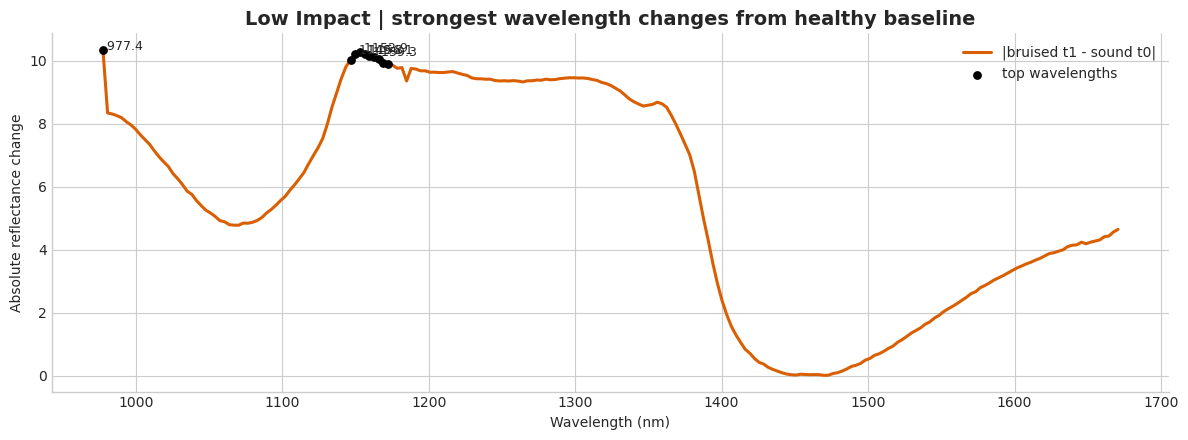

[Low Impact] Top 10 changing wavelengths: healthy t0 baseline vs bruised t3
1. wavelength=1264.2 nm: |Δ|=16.829781
2. wavelength=1261.0 nm: |Δ|=16.825340
3. wavelength=1267.3 nm: |Δ|=16.807869
4. wavelength=1257.8 nm: |Δ|=16.792282
5. wavelength=1270.5 nm: |Δ|=16.779610
6. wavelength=1254.6 nm: |Δ|=16.778076
7. wavelength=1273.7 nm: |Δ|=16.757317
8. wavelength=1251.5 nm: |Δ|=16.733910
9. wavelength=1248.3 nm: |Δ|=16.725136
10. wavelength=1276.9 nm: |Δ|=16.724785


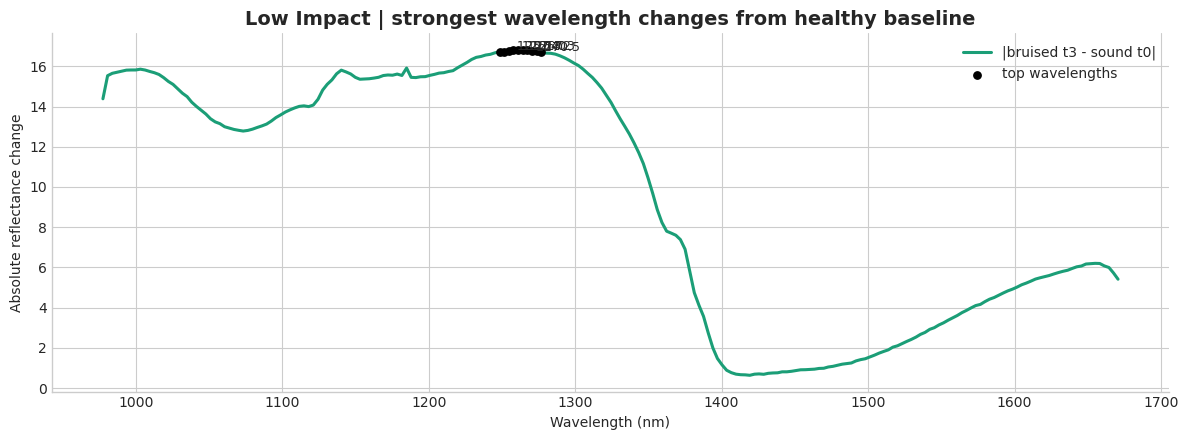

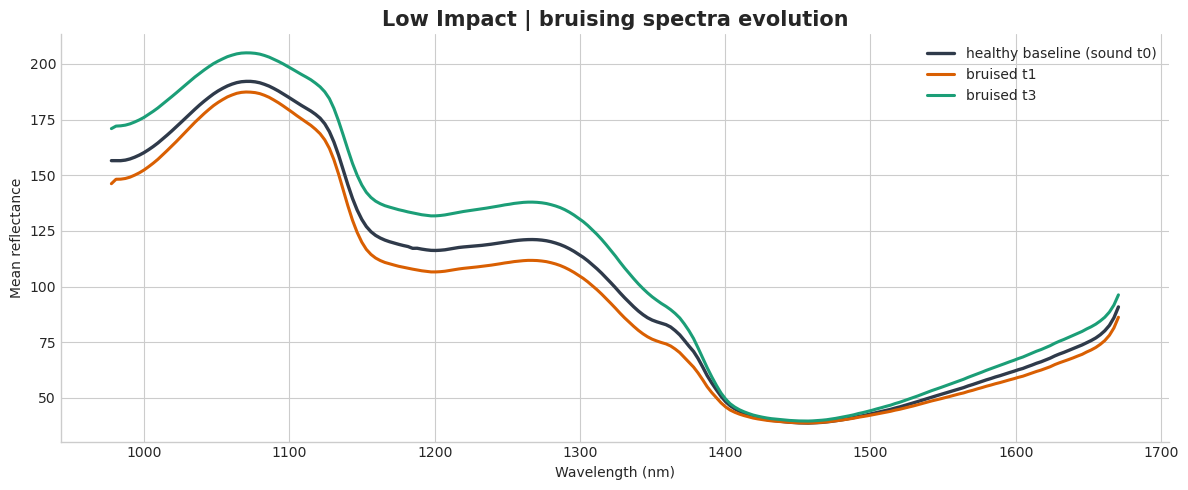

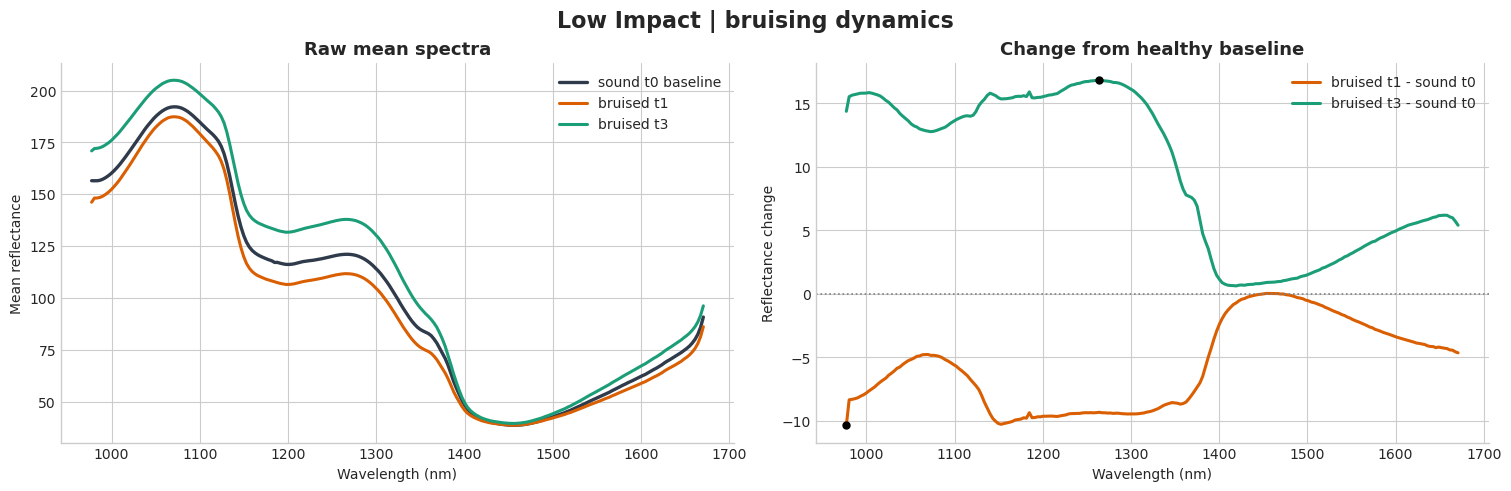

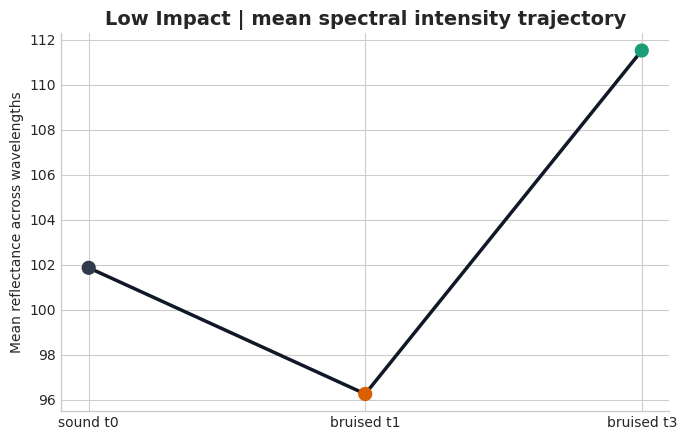

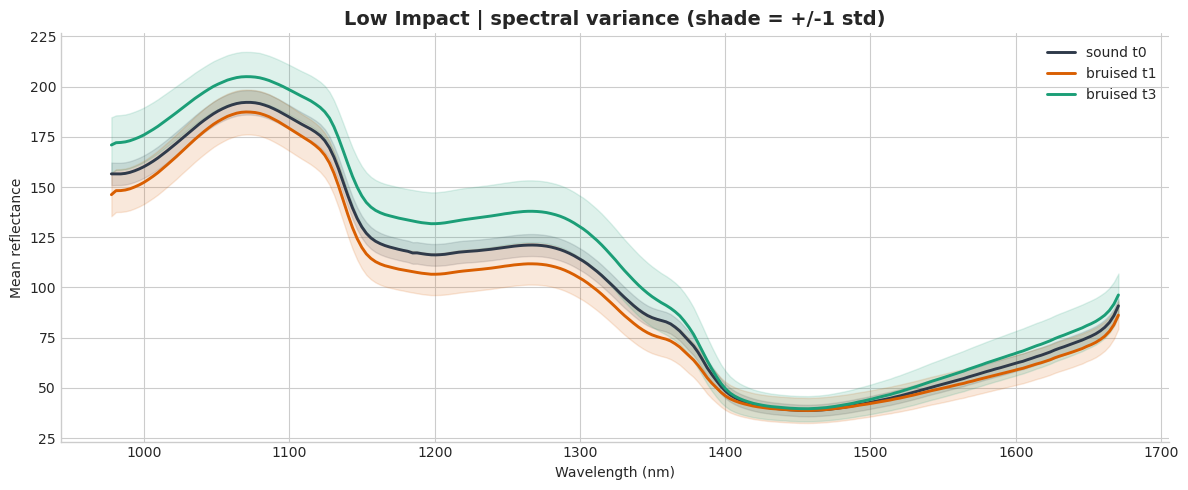

No wavelengths satisfy the non-overlap condition.
Non-overlap top wavelengths for low_impact: {'bands': [], 'scores': [], 'timepoints': []}

Impact group: High Impact | n=34


processed-box spectra: 100%|██████████| 34/34 [00:36<00:00,  1.08s/sample]

ROI / pixel counts used per timepoint:
  t0 baseline: sound_boxes=136, sound_pixels=3481600
  t1: bruised_boxes=136, bruised_pixels=54400, n_samples=34
  t3: bruised_boxes=136, bruised_pixels=54400, n_samples=34
[High Impact] Top 10 changing wavelengths: healthy t0 baseline vs bruised t1
1. wavelength=977.4 nm: |Δ|=18.753723
2. wavelength=1143.4 nm: |Δ|=18.124527
3. wavelength=1149.8 nm: |Δ|=18.121529
4. wavelength=1146.6 nm: |Δ|=18.118874
5. wavelength=1152.9 nm: |Δ|=18.053604
6. wavelength=1140.2 nm: |Δ|=17.977043
7. wavelength=1156.1 nm: |Δ|=17.931801
8. wavelength=1159.3 nm: |Δ|=17.855751
9. wavelength=1162.5 nm: |Δ|=17.793091
10. wavelength=1257.8 nm: |Δ|=17.783989


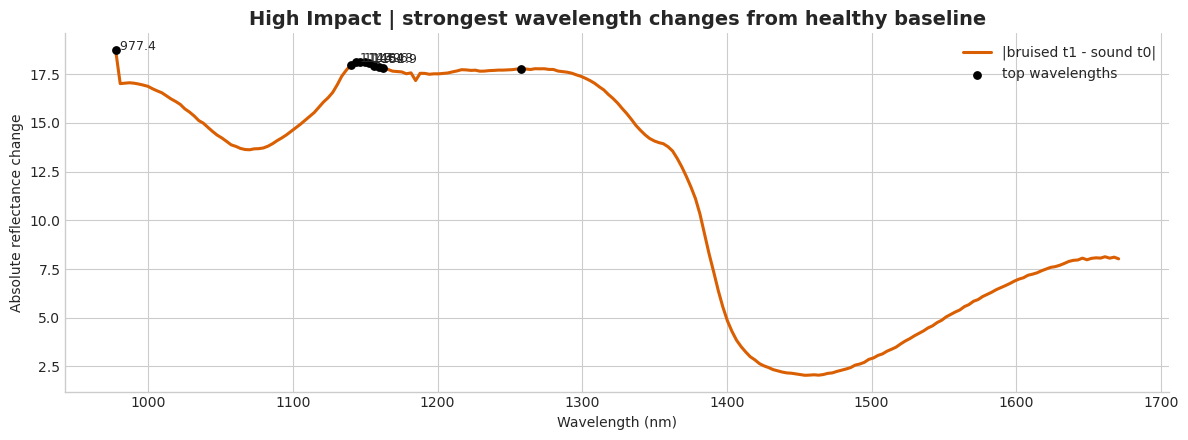

[High Impact] Top 10 changing wavelengths: healthy t0 baseline vs bruised t3
1. wavelength=1359.2 nm: |Δ|=20.380283
2. wavelength=1362.4 nm: |Δ|=20.312981
3. wavelength=1356.0 nm: |Δ|=20.286861
4. wavelength=1352.9 nm: |Δ|=20.038940
5. wavelength=1365.5 nm: |Δ|=19.964642
6. wavelength=1349.7 nm: |Δ|=19.820084
7. wavelength=1346.5 nm: |Δ|=19.647270
8. wavelength=1333.9 nm: |Δ|=19.635780
9. wavelength=1330.7 nm: |Δ|=19.630386
10. wavelength=1343.4 nm: |Δ|=19.608521


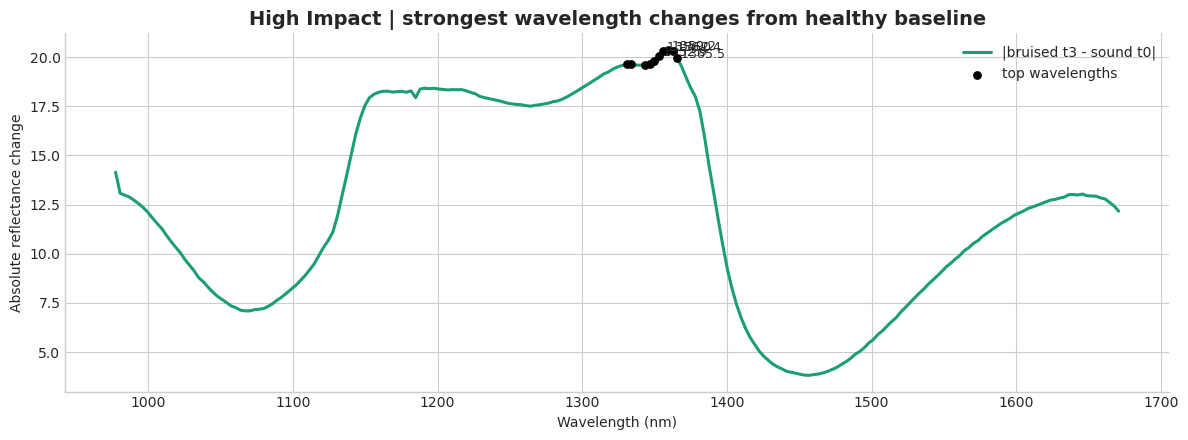

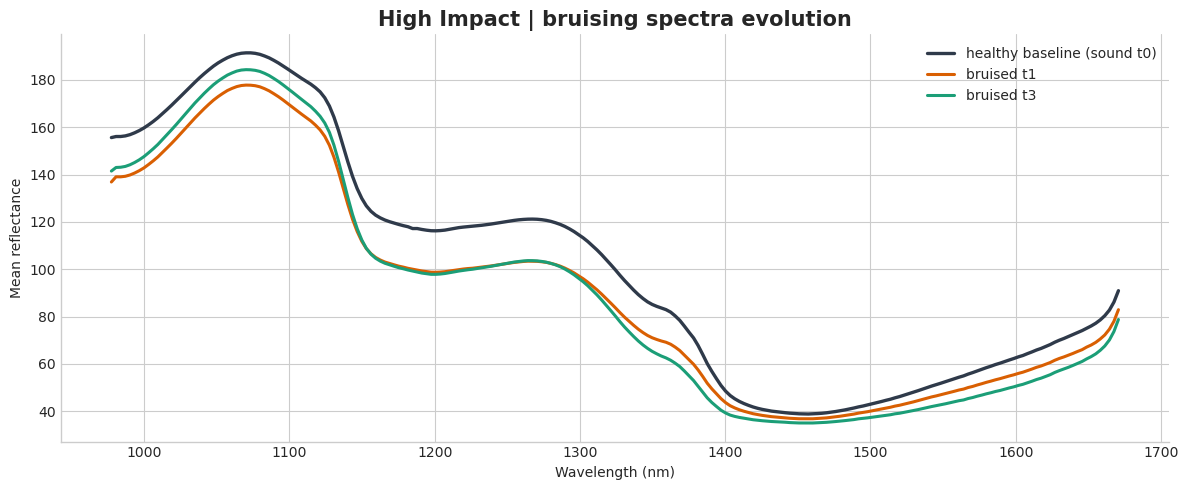

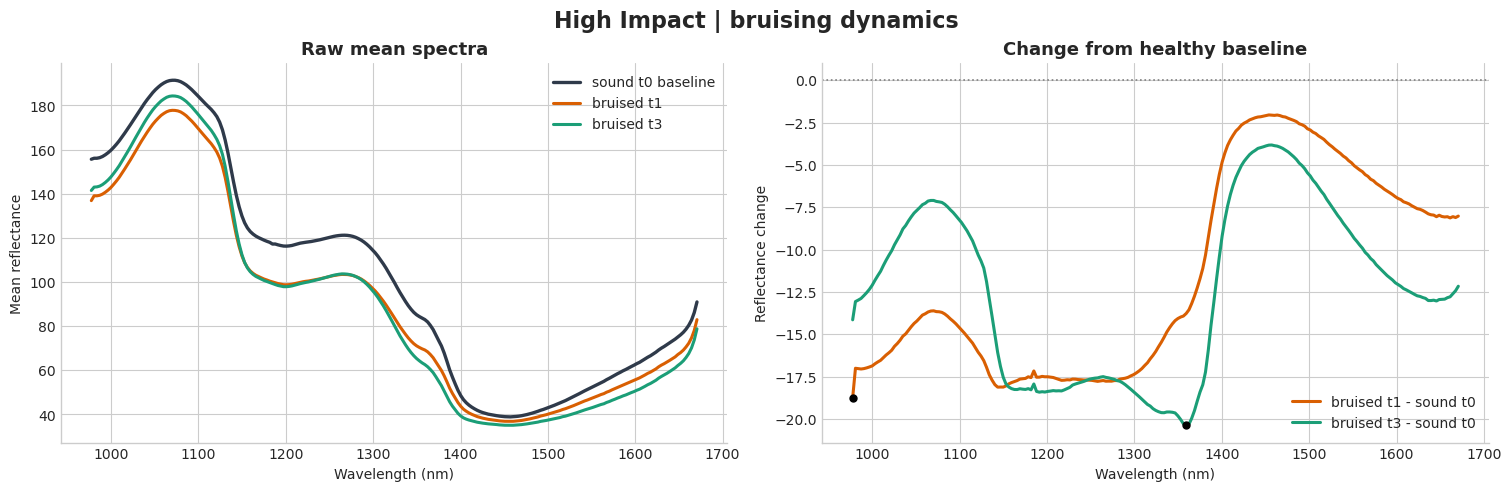

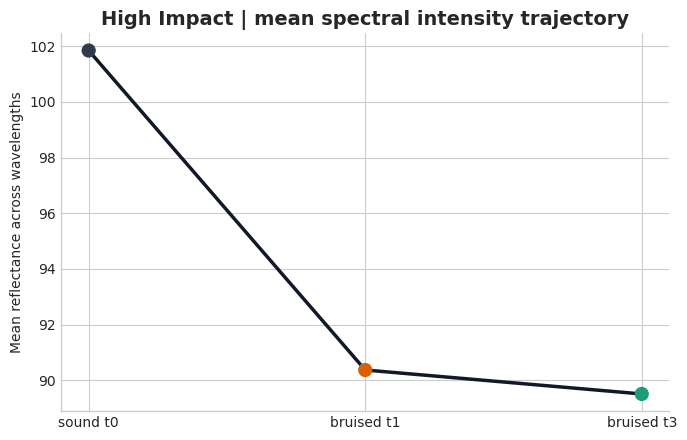

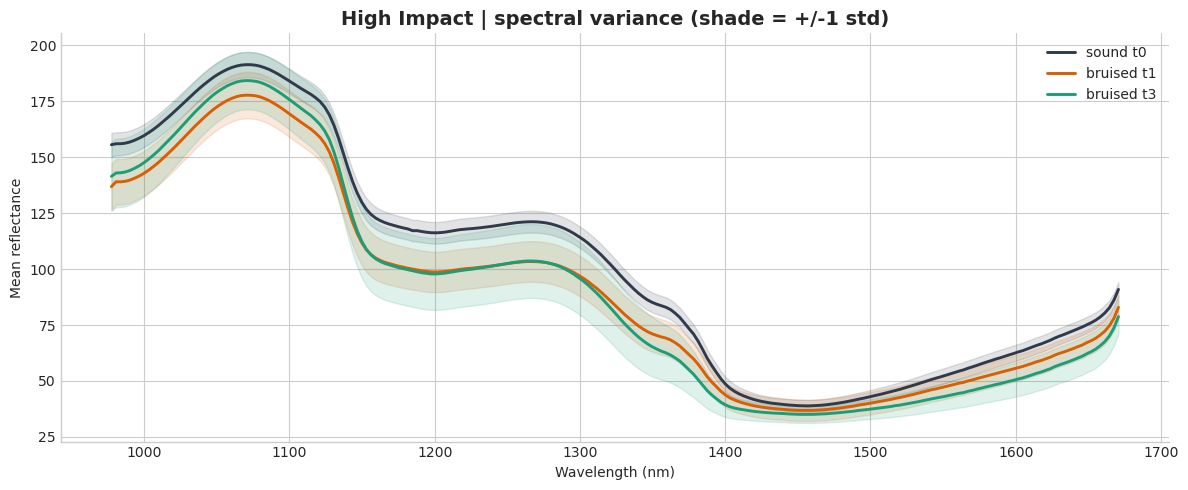

Non-overlap top wavelengths for high_impact: {'bands': [120, 121, 119, 118, 122, 117, 116, 112, 111, 115], 'scores': [20.38027572631836, 20.312976837158203, 20.28687286376953, 20.038955688476562, 19.964614868164062, 19.820053100585938, 19.647262573242188, 19.63581085205078, 19.63043212890625, 19.608535766601562], 'timepoints': ['t3', 't3', 't3', 't3', 't3', 't3', 't3', 't3', 't3', 't3']}


In [9]:
IMPACT_RESULTS = {}
for group_name in ['low_impact', 'high_impact']:
    IMPACT_RESULTS[group_name] = run_full_group_analysis(
        group_name,
        REQUESTED_GROUPS[group_name],
        top_k=TOP_K,
        show_boxplots=False,
        section_label='Impact group',
    )


## Impact group analyses complete

Low-impact and high-impact groups are compared using the t0 sound baseline and bruised spectra from later timepoints.


## Warm, Cold, and Whole Train+Validation Analyses

These blocks use the same train+validation H5 files already loaded from `data/splits/train` and `data/splits/val`. Warm and cold condition groups are analyzed separately, and the whole-sample block uses every complete train+validation sample.


**Condition and whole-sample summary**

,condition_group,n_samples
0,warm_condition,52
1,cold_condition,54
2,all_train_val_samples,106


**Condition group x timepoint box counts**

,condition_group,timepoint,samples,sound_boxes,bruised_boxes
0,warm_condition,t0,52,208,208
1,warm_condition,t1,52,208,208
2,warm_condition,t3,52,208,208
3,cold_condition,t0,54,216,216
4,cold_condition,t1,54,216,216
5,cold_condition,t3,54,216,216
6,all_train_val_samples,t0,106,424,424
7,all_train_val_samples,t1,106,424,424
8,all_train_val_samples,t3,106,424,424



Condition group: Warm Condition | n=52


processed-box spectra: 100%|██████████| 52/52 [00:54<00:00,  1.05s/sample]

ROI / pixel counts used per timepoint:
  t0 baseline: sound_boxes=208, sound_pixels=5324800
  t1: bruised_boxes=208, bruised_pixels=83200, n_samples=52
  t3: bruised_boxes=208, bruised_pixels=83200, n_samples=52
[Warm Condition] Top 10 changing wavelengths: healthy t0 baseline vs bruised t1
1. wavelength=1152.9 nm: |Δ|=14.934814
2. wavelength=1149.8 nm: |Δ|=14.918732
3. wavelength=1156.1 nm: |Δ|=14.860046
4. wavelength=1159.3 nm: |Δ|=14.798546
5. wavelength=1146.6 nm: |Δ|=14.774284
6. wavelength=1162.5 nm: |Δ|=14.743713
7. wavelength=1165.7 nm: |Δ|=14.667244
8. wavelength=1143.4 nm: |Δ|=14.574593
9. wavelength=1168.9 nm: |Δ|=14.556763
10. wavelength=1172.0 nm: |Δ|=14.531006


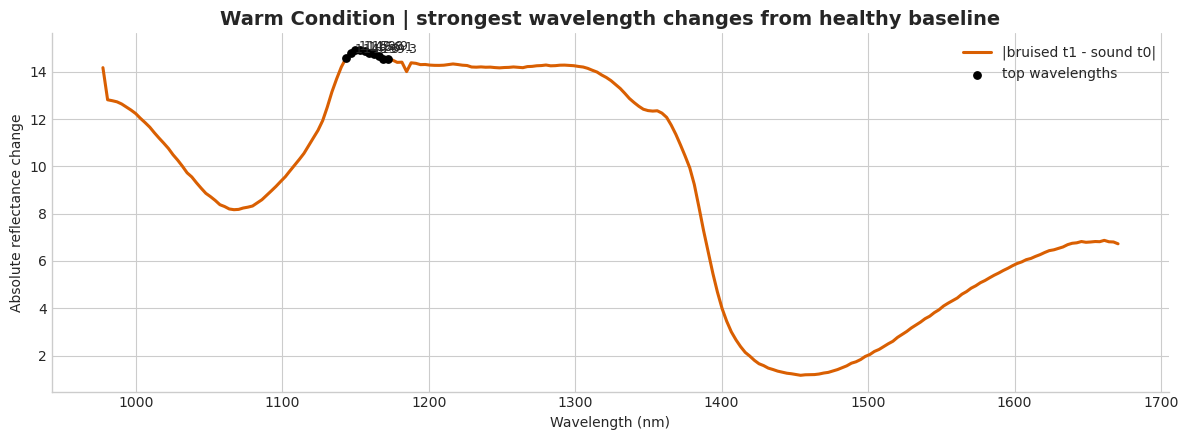

[Warm Condition] Top 10 changing wavelengths: healthy t0 baseline vs bruised t3
1. wavelength=1127.5 nm: |Δ|=8.015778
2. wavelength=1130.6 nm: |Δ|=8.012589
3. wavelength=977.4 nm: |Δ|=7.992828
4. wavelength=983.8 nm: |Δ|=7.871658
5. wavelength=980.6 nm: |Δ|=7.871338
6. wavelength=1133.8 nm: |Δ|=7.864304
7. wavelength=987.0 nm: |Δ|=7.826904
8. wavelength=1108.3 nm: |Δ|=7.819839
9. wavelength=1124.3 nm: |Δ|=7.810425
10. wavelength=1111.5 nm: |Δ|=7.810150


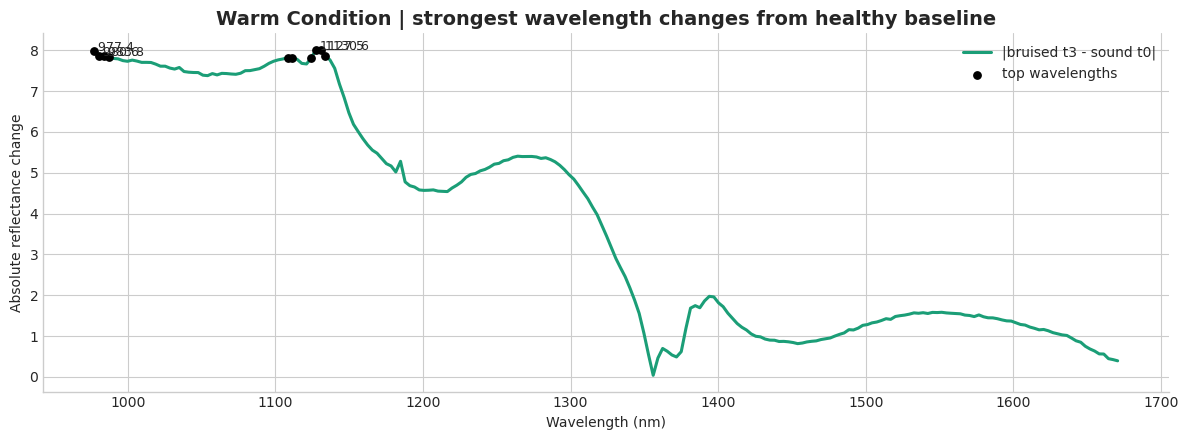

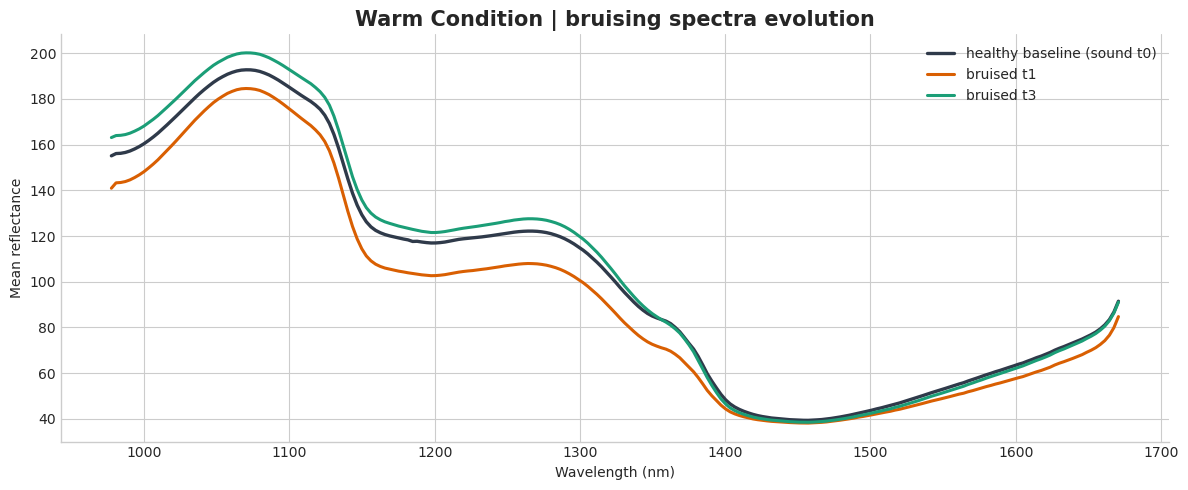

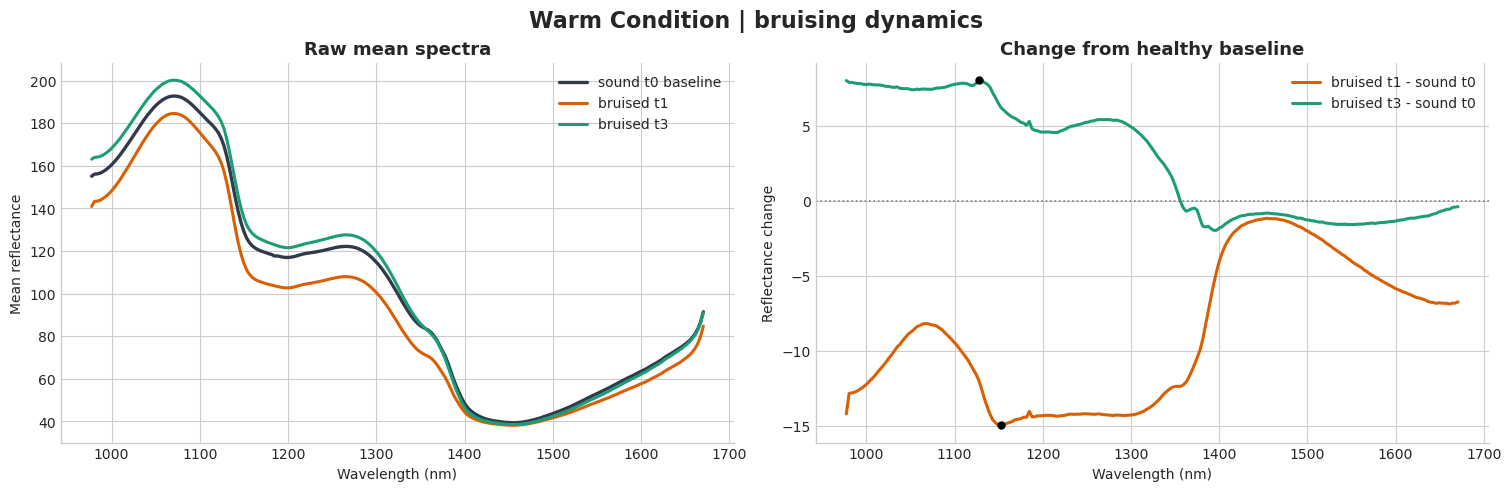

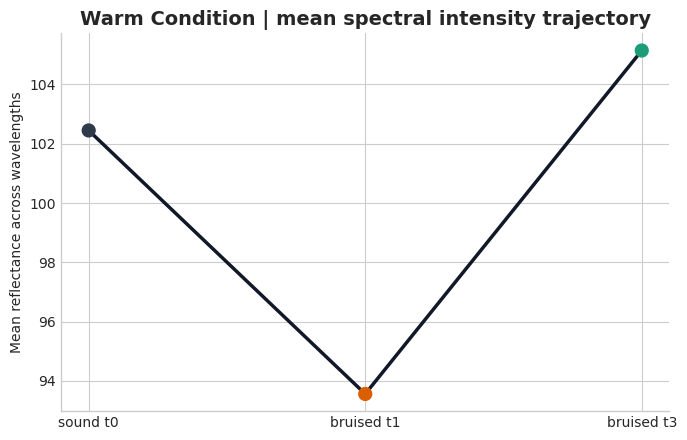

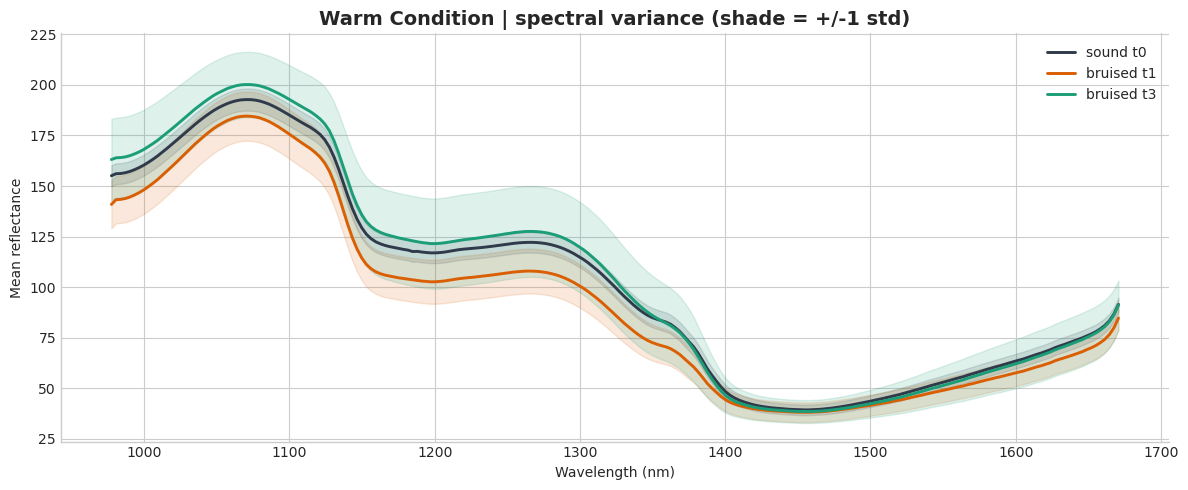

No wavelengths satisfy the non-overlap condition.
Non-overlap top wavelengths for warm_condition: {'bands': [], 'scores': [], 'timepoints': []}

Condition group: Cold Condition | n=54


processed-box spectra: 100%|██████████| 54/54 [00:59<00:00,  1.10s/sample]

ROI / pixel counts used per timepoint:
  t0 baseline: sound_boxes=216, sound_pixels=5529600
  t1: bruised_boxes=216, bruised_pixels=86400, n_samples=54
  t3: bruised_boxes=216, bruised_pixels=86400, n_samples=54
[Cold Condition] Top 10 changing wavelengths: healthy t0 baseline vs bruised t1
1. wavelength=977.4 nm: |Δ|=11.960281
2. wavelength=1152.9 nm: |Δ|=10.675957
3. wavelength=1149.8 nm: |Δ|=10.658318
4. wavelength=1156.1 nm: |Δ|=10.585320
5. wavelength=1146.6 nm: |Δ|=10.560760
6. wavelength=1159.3 nm: |Δ|=10.538818
7. wavelength=1162.5 nm: |Δ|=10.480316
8. wavelength=1143.4 nm: |Δ|=10.452652
9. wavelength=1165.7 nm: |Δ|=10.426590
10. wavelength=1168.9 nm: |Δ|=10.330215


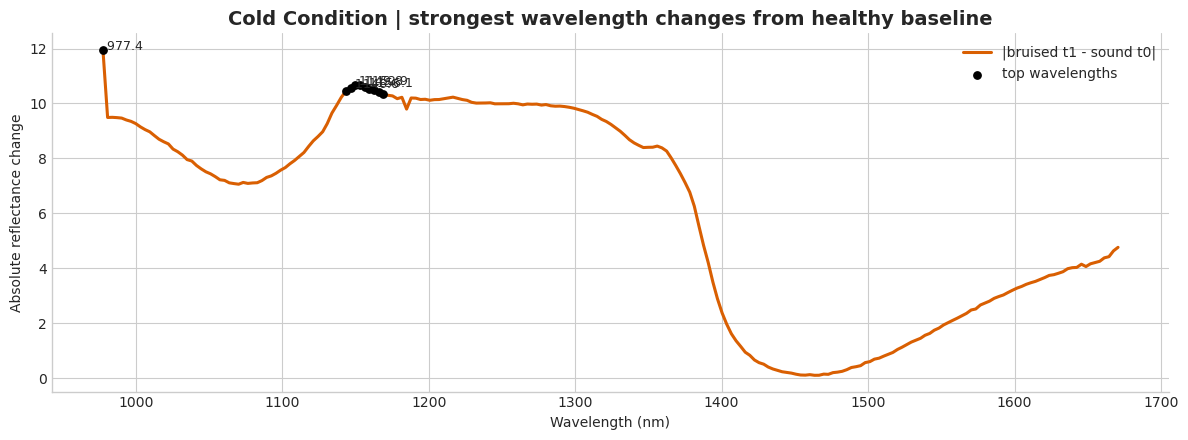

[Cold Condition] Top 10 changing wavelengths: healthy t0 baseline vs bruised t3
1. wavelength=1018.9 nm: |Δ|=6.694733
2. wavelength=1025.3 nm: |Δ|=6.688889
3. wavelength=1015.7 nm: |Δ|=6.683044
4. wavelength=1022.1 nm: |Δ|=6.663361
5. wavelength=1028.5 nm: |Δ|=6.624222
6. wavelength=1012.5 nm: |Δ|=6.598328
7. wavelength=1031.7 nm: |Δ|=6.537872
8. wavelength=1034.9 nm: |Δ|=6.497208
9. wavelength=1009.4 nm: |Δ|=6.471146
10. wavelength=1006.2 nm: |Δ|=6.373825


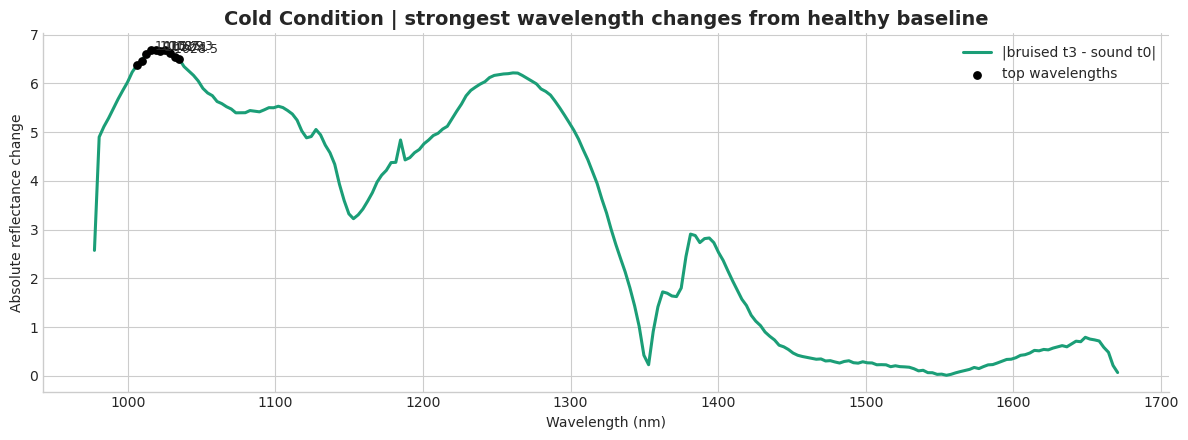

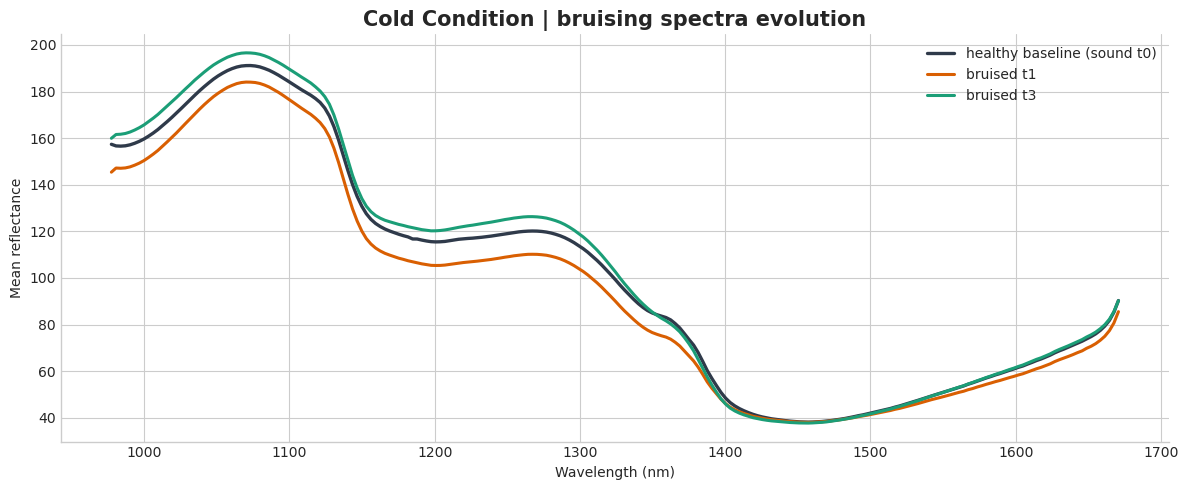

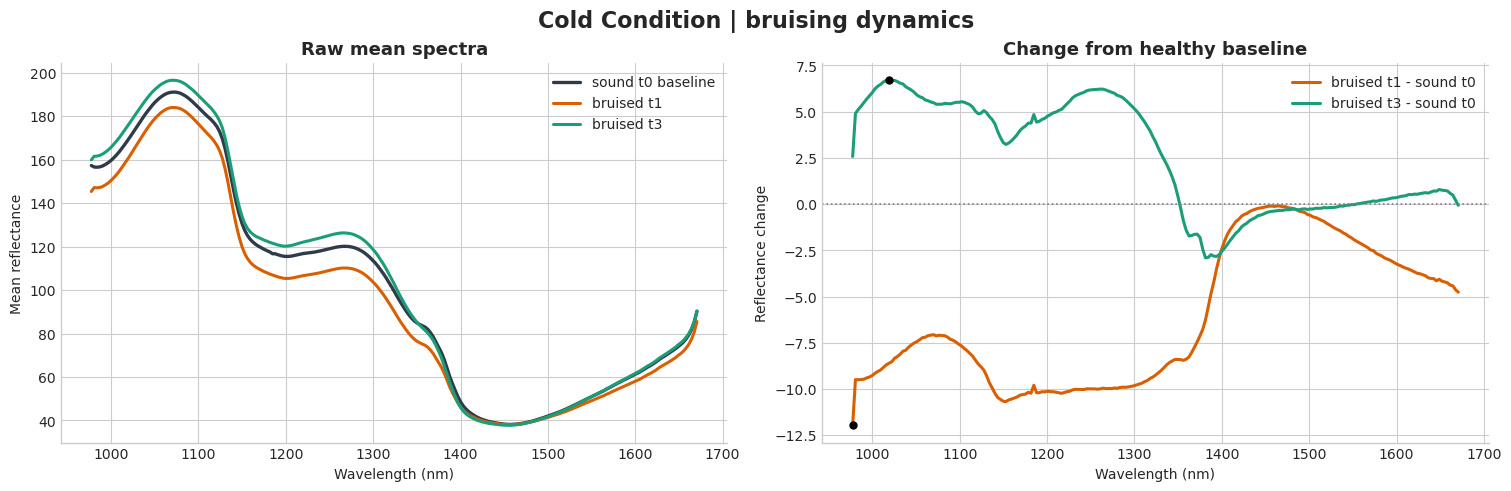

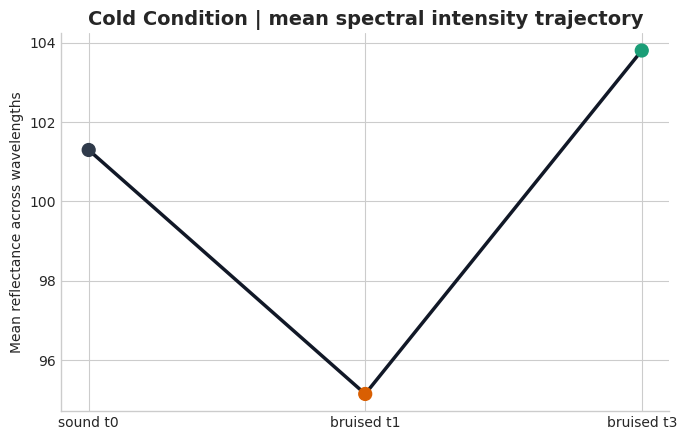

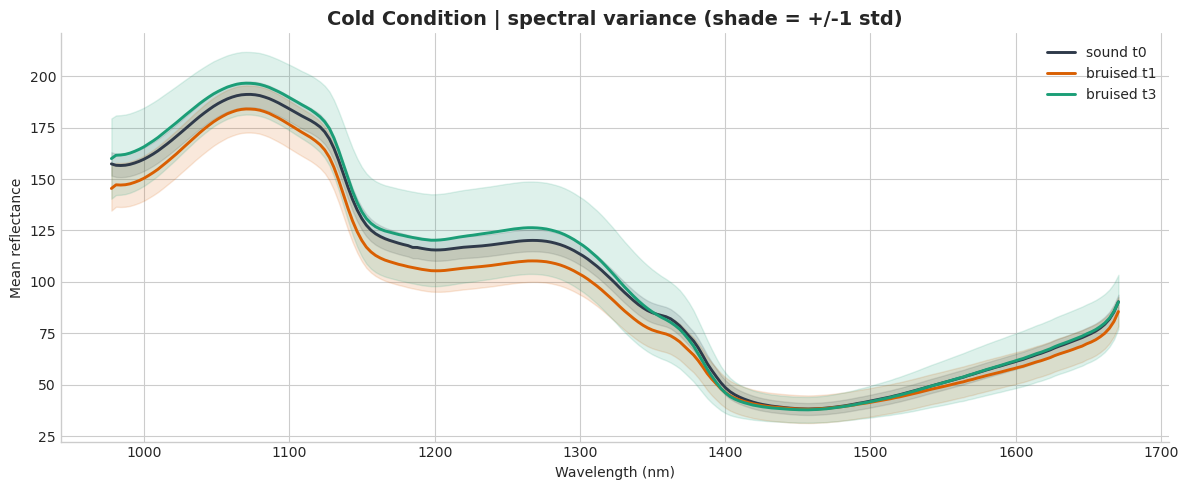

No wavelengths satisfy the non-overlap condition.
Non-overlap top wavelengths for cold_condition: {'bands': [], 'scores': [], 'timepoints': []}

Whole train+validation sample: All Train+Validation Samples | n=106


processed-box spectra: 100%|██████████| 106/106 [01:52<00:00,  1.06s/sample]

ROI / pixel counts used per timepoint:
  t0 baseline: sound_boxes=424, sound_pixels=10854400
  t1: bruised_boxes=424, bruised_pixels=169600, n_samples=106
  t3: bruised_boxes=424, bruised_pixels=169600, n_samples=106
[All Train+Validation Samples] Top 10 changing wavelengths: healthy t0 baseline vs bruised t1
1. wavelength=977.4 nm: |Δ|=13.045105
2. wavelength=1152.9 nm: |Δ|=12.765213
3. wavelength=1149.8 nm: |Δ|=12.748337
4. wavelength=1156.1 nm: |Δ|=12.682350
5. wavelength=1159.3 nm: |Δ|=12.628494
6. wavelength=1146.6 nm: |Δ|=12.627777
7. wavelength=1162.5 nm: |Δ|=12.571793
8. wavelength=1165.7 nm: |Δ|=12.506912
9. wavelength=1143.4 nm: |Δ|=12.474747
10. wavelength=1168.9 nm: |Δ|=12.403618


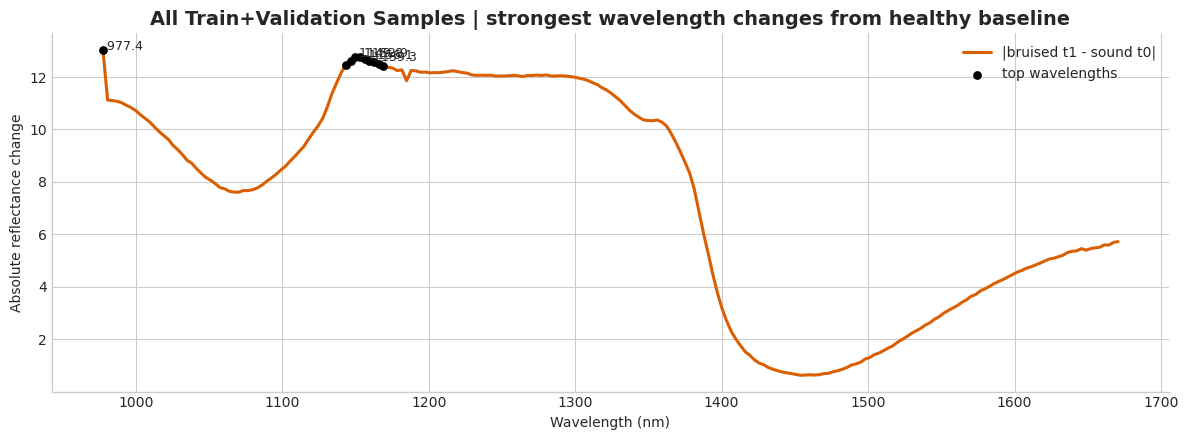

[All Train+Validation Samples] Top 10 changing wavelengths: healthy t0 baseline vs bruised t3
1. wavelength=1015.7 nm: |Δ|=7.182205
2. wavelength=1018.9 nm: |Δ|=7.168488
3. wavelength=1025.3 nm: |Δ|=7.140778
4. wavelength=1012.5 nm: |Δ|=7.140503
5. wavelength=1022.1 nm: |Δ|=7.127808
6. wavelength=1028.5 nm: |Δ|=7.085144
7. wavelength=1009.4 nm: |Δ|=7.075470
8. wavelength=1006.2 nm: |Δ|=7.041595
9. wavelength=1031.7 nm: |Δ|=7.029083
10. wavelength=1034.9 nm: |Δ|=7.027344


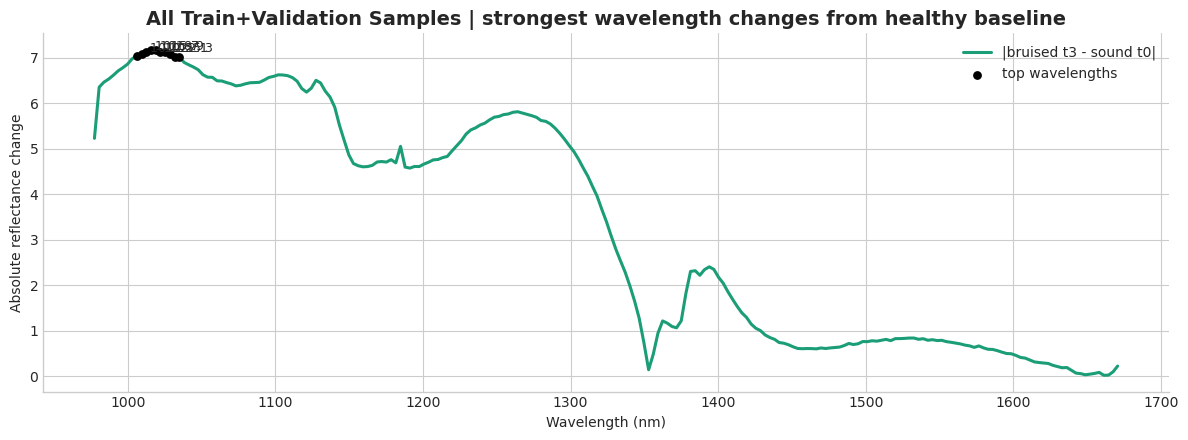

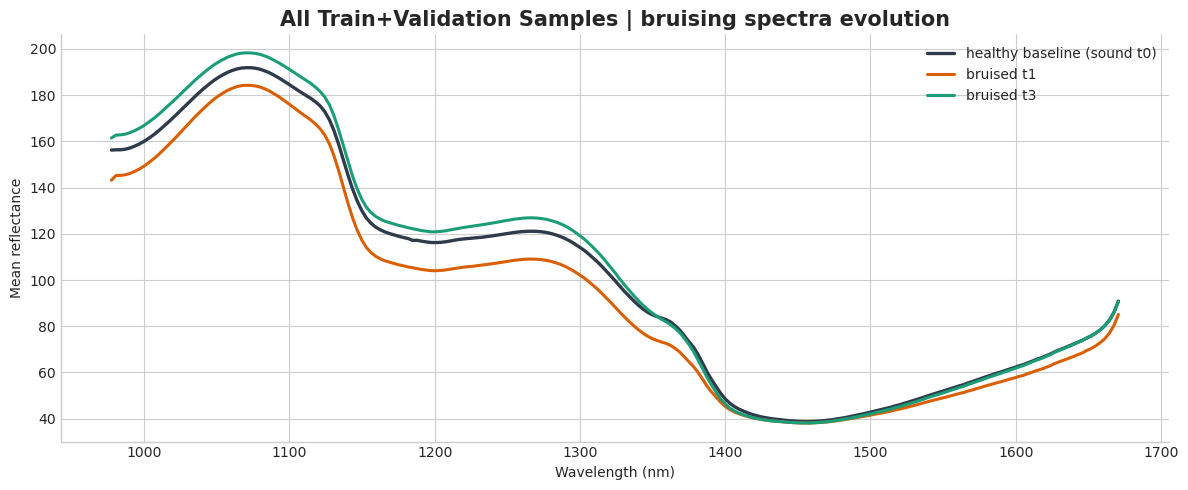

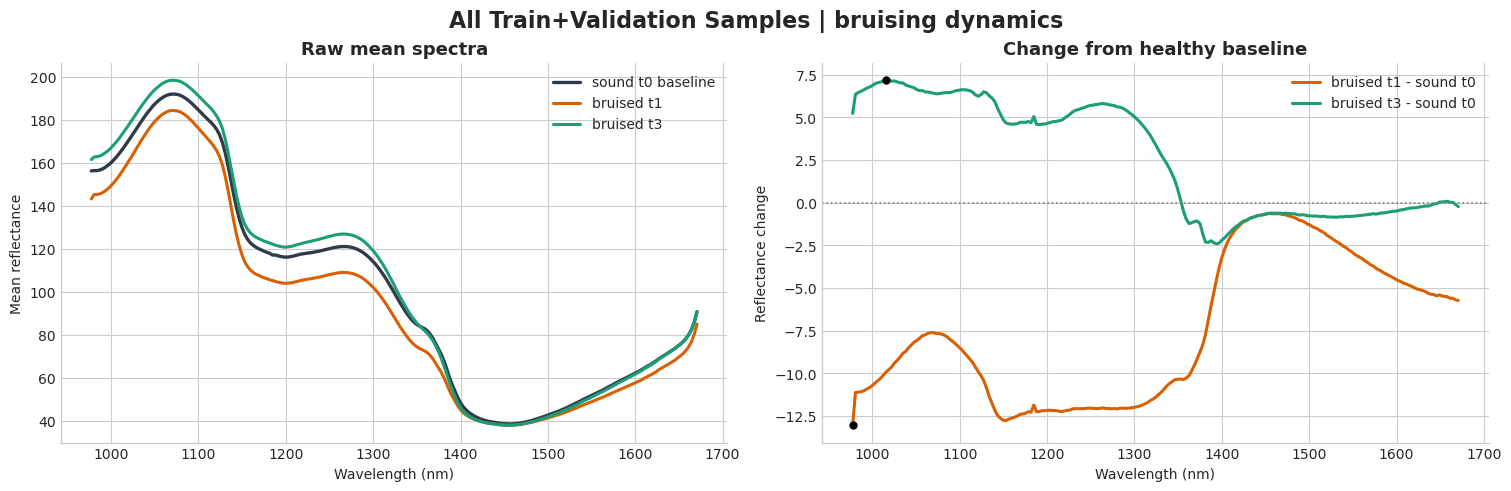

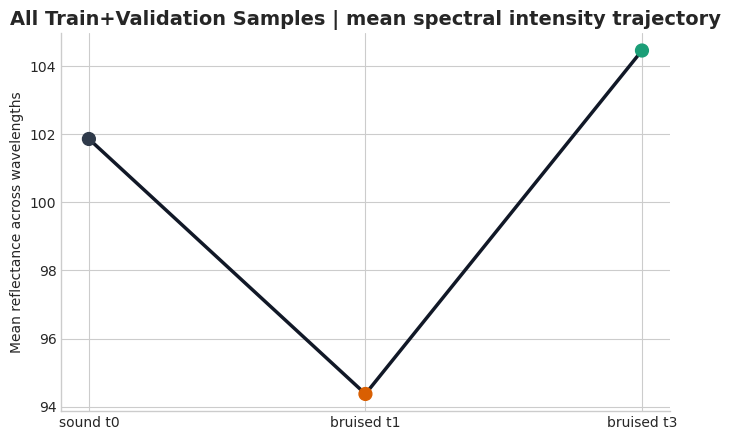

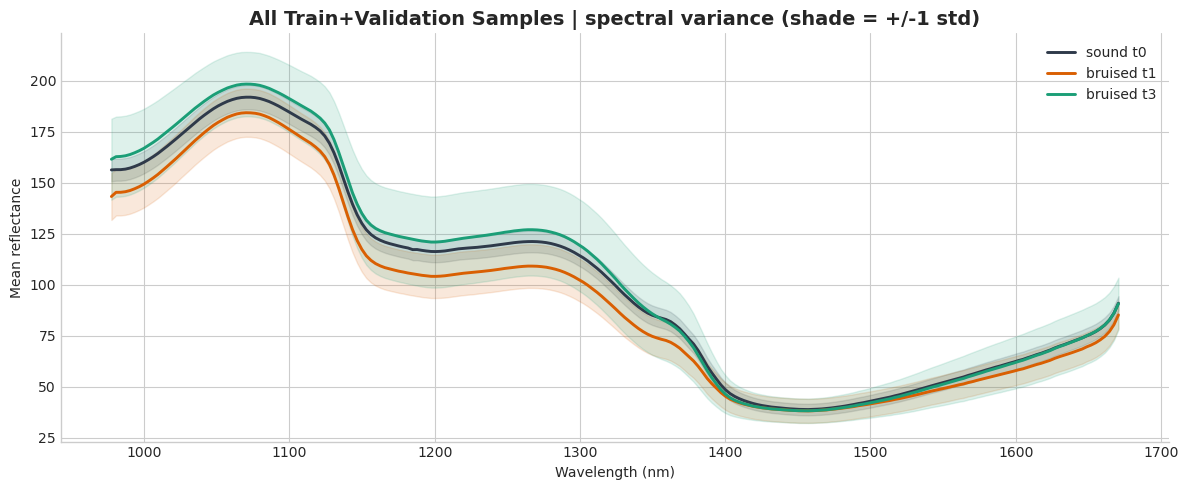

No wavelengths satisfy the non-overlap condition.
Non-overlap top wavelengths for all_train_val_samples: {'bands': [], 'scores': [], 'timepoints': []}


In [10]:
WARM_PREFIXES = ('28',)
COLD_PREFIXES = ('29',)

CONDITION_GROUPS = {
    'warm_condition': codes_for_prefixes(WARM_PREFIXES),
    'cold_condition': codes_for_prefixes(COLD_PREFIXES),
    'all_train_val_samples': sorted(complete_codes),
}

condition_summary_rows = []
condition_timepoint_rows = []
for name, codes in CONDITION_GROUPS.items():
    group_inventory = inventory_df[inventory_df['sample_code'].isin(codes)].copy()
    condition_summary_rows.append({
        'condition_group': name,
        'n_samples': len(codes),
    })
    for timepoint in TIMEPOINTS:
        subset = group_inventory[group_inventory['timepoint'] == timepoint]
        condition_timepoint_rows.append({
            'condition_group': name,
            'timepoint': timepoint,
            'samples': subset['sample_code'].nunique(),
            'sound_boxes': int(subset['sound_boxes'].sum()),
            'bruised_boxes': int(subset['bruised_boxes'].sum()),
        })

condition_summary_df = pd.DataFrame(condition_summary_rows)
condition_timepoint_df = pd.DataFrame(condition_timepoint_rows)

display(Markdown('**Condition and whole-sample summary**'))
display(condition_summary_df)

display(Markdown('**Condition group x timepoint box counts**'))
display(condition_timepoint_df)

CONDITION_RESULTS = {}
for group_name, sample_codes in CONDITION_GROUPS.items():
    label = 'Whole train+validation sample' if group_name == 'all_train_val_samples' else 'Condition group'
    CONDITION_RESULTS[group_name] = run_full_group_analysis(
        group_name,
        sample_codes,
        top_k=TOP_K,
        show_boxplots=False,
        section_label=label,
    )


In [11]:
# Simple t0 healthy vs damaged comparison using paired sample-level means.
from scipy import stats

T0_SAMPLE_CODES = sorted({code for codes in REQUESTED_GROUPS.values() for code in codes})

t0_rows = []
for sample_code in T0_SAMPLE_CODES:
    sound_cubes = load_box_cubes(sample_code, 't0', 'sound')
    bruised_cubes = load_box_cubes(sample_code, 't0', 'bruised')

    sound_box_spectra = np.stack([cube_band_values(cube).mean(axis=0) for cube in sound_cubes], axis=0)
    bruised_box_spectra = np.stack([cube_band_values(cube).mean(axis=0) for cube in bruised_cubes], axis=0)

    sound_sample_mean = sound_box_spectra.mean(axis=0)
    bruised_sample_mean = bruised_box_spectra.mean(axis=0)

    t0_rows.append({
        'sample_code': sample_code,
        'sound_mean_t0': float(sound_sample_mean.mean()),
        'bruised_mean_t0': float(bruised_sample_mean.mean()),
        'delta_bruised_minus_sound': float(bruised_sample_mean.mean() - sound_sample_mean.mean()),
    })

t0_compare_df = pd.DataFrame(t0_rows).sort_values('sample_code').reset_index(drop=True)

sound_vals = t0_compare_df['sound_mean_t0'].to_numpy(dtype=float)
bruised_vals = t0_compare_df['bruised_mean_t0'].to_numpy(dtype=float)

paired_t = stats.ttest_rel(bruised_vals, sound_vals)
wilcoxon_result = stats.wilcoxon(bruised_vals, sound_vals, alternative='two-sided')

display(Markdown(
    '**t0 damaged vs healthy comparison**  \
'
    '- Unit of analysis: one paired observation per sample (sample-level mean spectrum averaged over boxes and bands).  \
'
    '- Tests: paired t-test and Wilcoxon signed-rank test.'
))

display(t0_compare_df)

t0_test_summary_df = pd.DataFrame([
    {
        'test': 'paired t-test',
        'n_samples': int(len(t0_compare_df)),
        'sound_mean': float(sound_vals.mean()),
        'bruised_mean': float(bruised_vals.mean()),
        'mean_delta_bruised_minus_sound': float((bruised_vals - sound_vals).mean()),
        'statistic': float(paired_t.statistic),
        'p_value': float(paired_t.pvalue),
    },
    {
        'test': 'Wilcoxon signed-rank',
        'n_samples': int(len(t0_compare_df)),
        'sound_mean': float(sound_vals.mean()),
        'bruised_mean': float(bruised_vals.mean()),
        'mean_delta_bruised_minus_sound': float((bruised_vals - sound_vals).mean()),
        'statistic': float(wilcoxon_result.statistic),
        'p_value': float(wilcoxon_result.pvalue),
    },
])

display(t0_test_summary_df)


**t0 damaged vs healthy comparison**  - Unit of analysis: one paired observation per sample (sample-level mean spectrum averaged over boxes and bands).  - Tests: paired t-test and Wilcoxon signed-rank test.

,sample_code,sound_mean_t0,bruised_mean_t0,delta_bruised_minus_sound
0,28002,107.849617,113.775917,5.926300
1,28003,104.421043,108.215179,3.794136
2,28004,98.696030,105.548187,6.852158
3,28005,101.550163,111.175926,9.625763
4,28006,105.844017,111.861328,6.017311
...,...,...,...,...
101,29504,100.938362,111.542770,10.604408
102,29506,100.795425,107.620567,6.825142
103,29507,99.673561,100.905548,1.231987
104,29508,104.884605,109.009895,4.125290


,test,n_samples,sound_mean,bruised_mean,mean_delta_bruised_minus_sound,statistic,p_value
0,paired t-test,106,101.861618,104.418933,2.557315,6.020917,2.584599e-08
1,Wilcoxon signed-rank,106,101.861618,104.418933,2.557315,1198.000000,2.453467e-07


/tmp/ipykernel_2752452/1713093635.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([baseline_vals[:, band_index], bruised_vals], labels=['sound t0', f'bruised {timepoint}'], patch_artist=True)
/tmp/ipykernel_2752452/1713093635.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([baseline_vals[:, band_index], bruised_vals], labels=['sound t0', f'bruised {timepoint}'], patch_artist=True)
/tmp/ipykernel_2752452/1713093635.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([baseline_vals[:, band_index], bruised_vals], labels=['sound t0', f'bruised {timepoint}'], patch_artist=True)
/

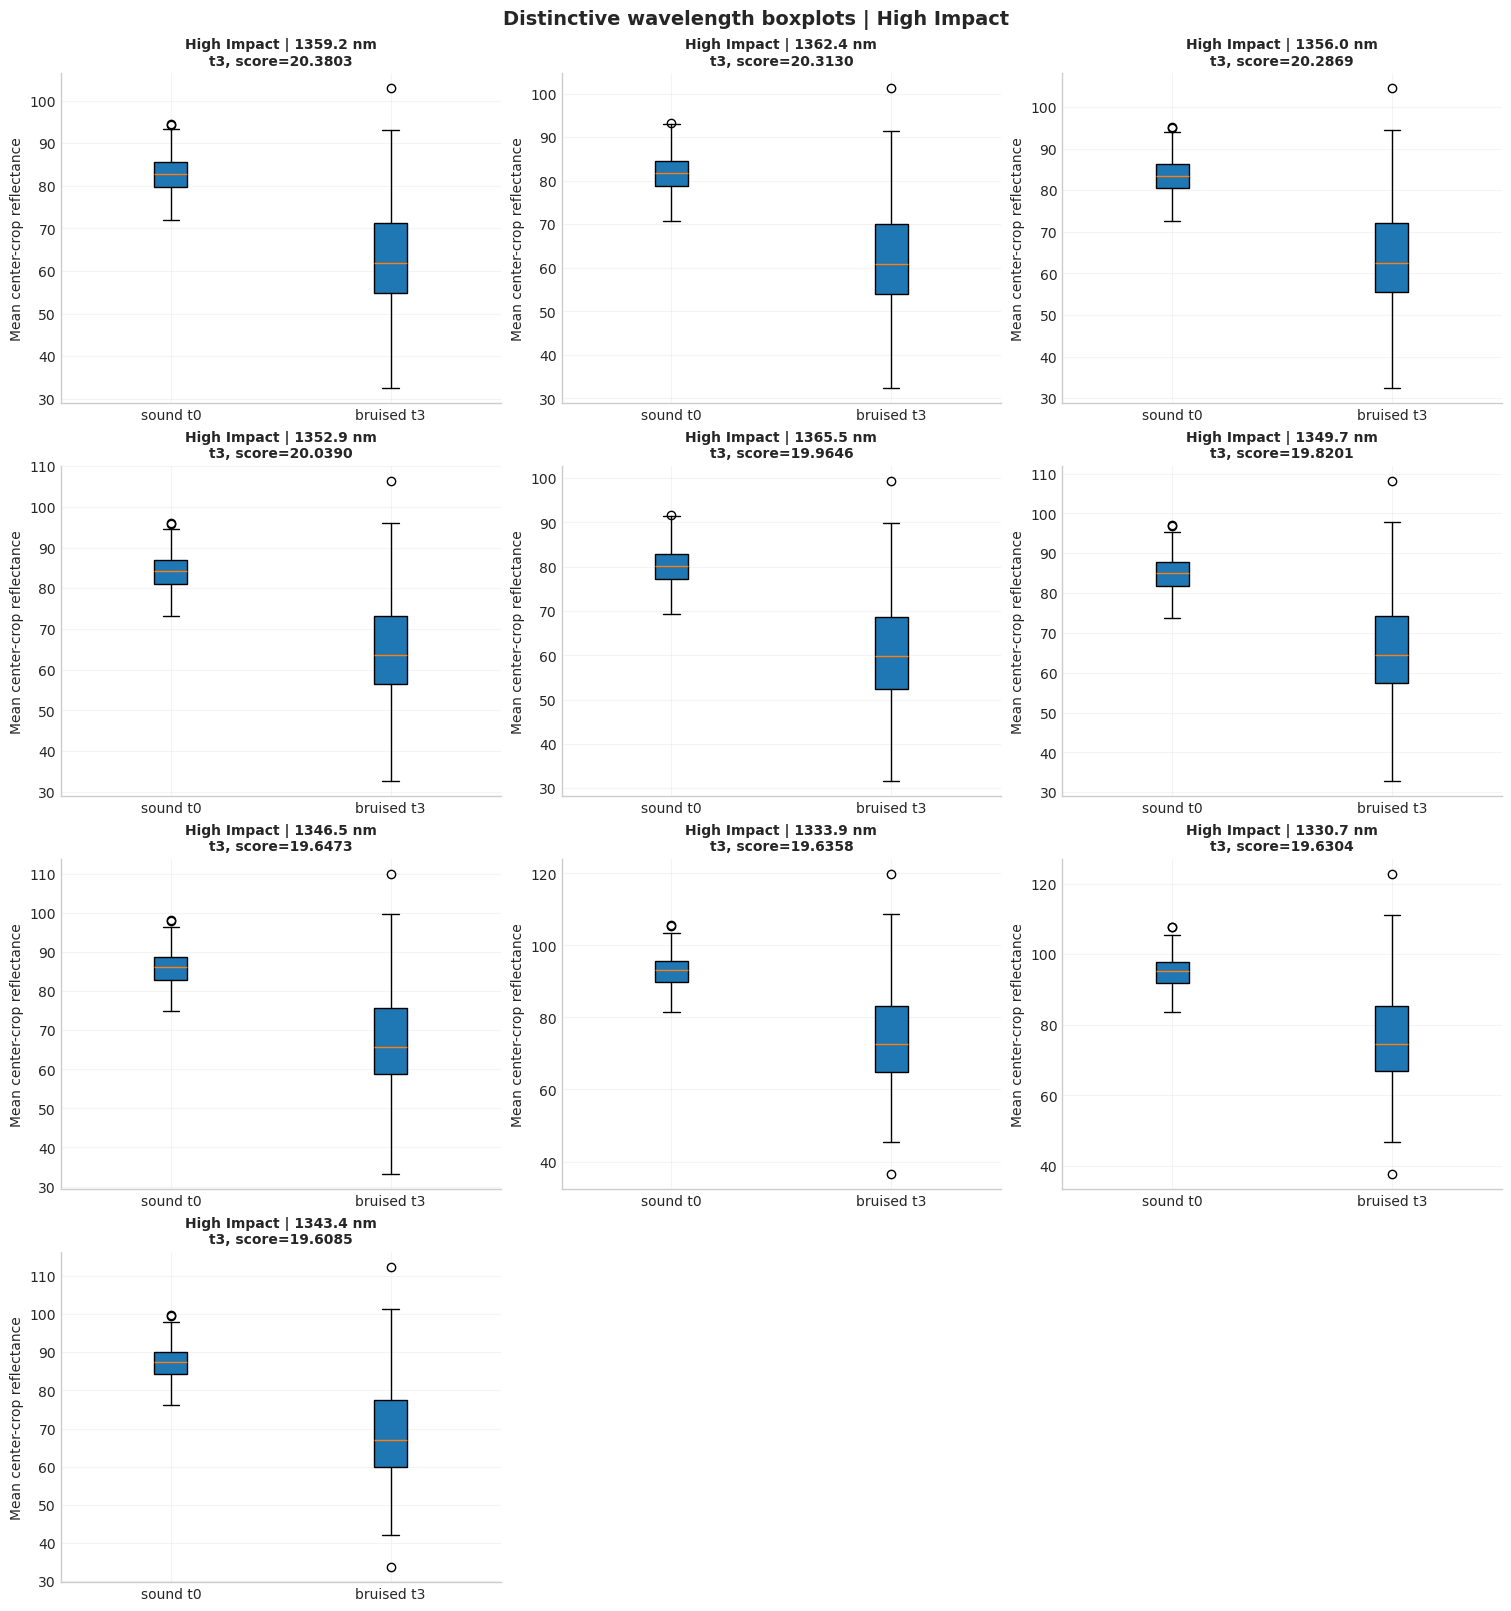

In [12]:
# Optional: boxplots for one already-computed impact group.
GROUP_FOR_BOXPLOTS = 'high_impact'

result_bundle = IMPACT_RESULTS[GROUP_FOR_BOXPLOTS]
boxplot_distinctive_bands(
    result_bundle['group_data'],
    result_bundle['topk_result'],
    GROUP_FOR_BOXPLOTS,
)
